In [5]:
# Verify notebook training dependencies

import importlib.util

required_modules = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
    "shap": "shap",
    "imbalanced-learn": "imblearn",
    "joblib": "joblib",
    "scipy": "scipy",
}

missing = [pkg for pkg, module in required_modules.items() if importlib.util.find_spec(module) is None]
if missing:
    raise RuntimeError(f"Missing packages: {', '.join(missing)}. Run: pip install -r requirements.txt")

print(" Notebook training dependencies are available.")

 Notebook training dependencies are available.


In [6]:
# IMPORTS

import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib
import json
from datetime import datetime

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# SHAP
import shap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Business cost constants (per problem statement)
FN_COST = 40_000   # ₹ cost of missing a churner
FP_COST = 500      # ₹ cost of unnecessary retention spend

# Paths
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Churnzero_data").exists():
    PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "Churnzero_data" / "CZ_raw"
TRAIN_PATH = DATA_DIR / "ChurnZero_dataset_v1.csv"
TEST_PATH = DATA_DIR / "ChurnZero_test_v1.csv"
OUTPUT_DIR = PROJECT_ROOT / "retention_flow_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(" Imports complete. Output directory:", OUTPUT_DIR)
print(f"   Business Cost → FN: ₹{FN_COST:,}  |  FP: ₹{FP_COST:,}")

 Imports complete. Output directory: C:\Users\DELL\RetentionFlow\retention_flow_outputs
   Business Cost → FN: ₹40,000  |  FP: ₹500


In [7]:
# DATA LOADING & VALIDATION


df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print("=" * 60)
print(" RETENTIONFLOW — DATA VALIDATION REPORT")
print("=" * 60)
print(f"\n Training set : {df_train.shape[0]:,} rows × {df_train.shape[1]} cols")
print(f" Test set     : {df_test.shape[0]:,} rows × {df_test.shape[1]} cols")

# Target distribution
churn_counts = df_train["churn"].value_counts()
churn_rate   = df_train["churn"].mean() * 100
print(f"\n Churn Distribution:")
print(f"   Non-Churn (0) : {churn_counts[0]:,}  ({100 - churn_rate:.1f}%)")
print(f"   Churn     (1) : {churn_counts[1]:,}  ({churn_rate:.1f}%)")
print(f"   Imbalance Ratio : {churn_counts[0]/churn_counts[1]:.1f}:1")

# Missing values
missing_train = df_train.isnull().sum()
missing_pct   = (missing_train / len(df_train) * 100).round(2)
miss_df       = pd.DataFrame({"Missing": missing_train, "Pct%": missing_pct})
miss_df       = miss_df[miss_df["Missing"] > 0].sort_values("Pct%", ascending=False)

print(f"\n Missing Values (train): {len(miss_df)} columns affected")
if len(miss_df) > 0:
    print(miss_df.head(10).to_string())
else:
    print("   → No missing values found.")

# Duplicates
dup_count = df_train.duplicated(subset=["customer_id"]).sum()
print(f"\n Duplicate customer_ids: {dup_count}")

print("\n" + "=" * 60)
print(" Data types summary:")
print(df_train.dtypes.value_counts().to_string())
print("=" * 60)

 RETENTIONFLOW — DATA VALIDATION REPORT

 Training set : 8,101 rows × 98 cols
 Test set     : 2,026 rows × 97 cols

 Churn Distribution:
   Non-Churn (0) : 6,799  (83.9%)
   Churn     (1) : 1,302  (16.1%)
   Imbalance Ratio : 5.2:1

 Missing Values (train): 1 columns affected
                  Missing    Pct%
app_rating_given     4541 56.0500

 Duplicate customer_ids: 0

 Data types summary:
int64      60
float64    23
str        15


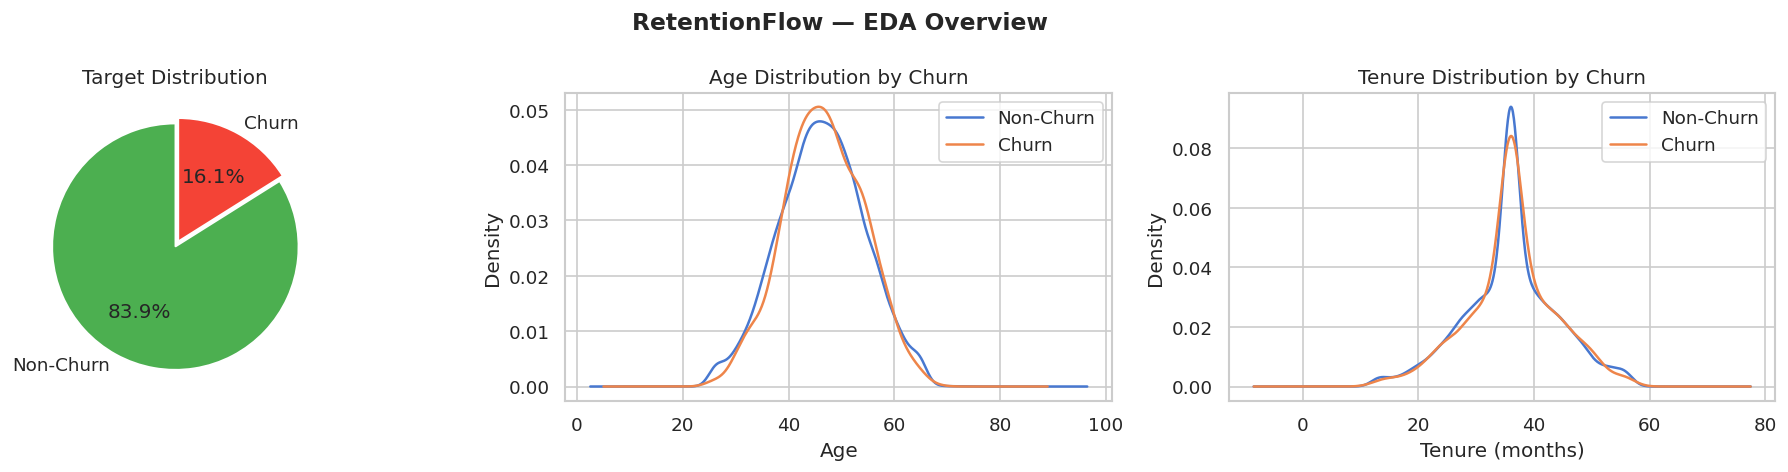

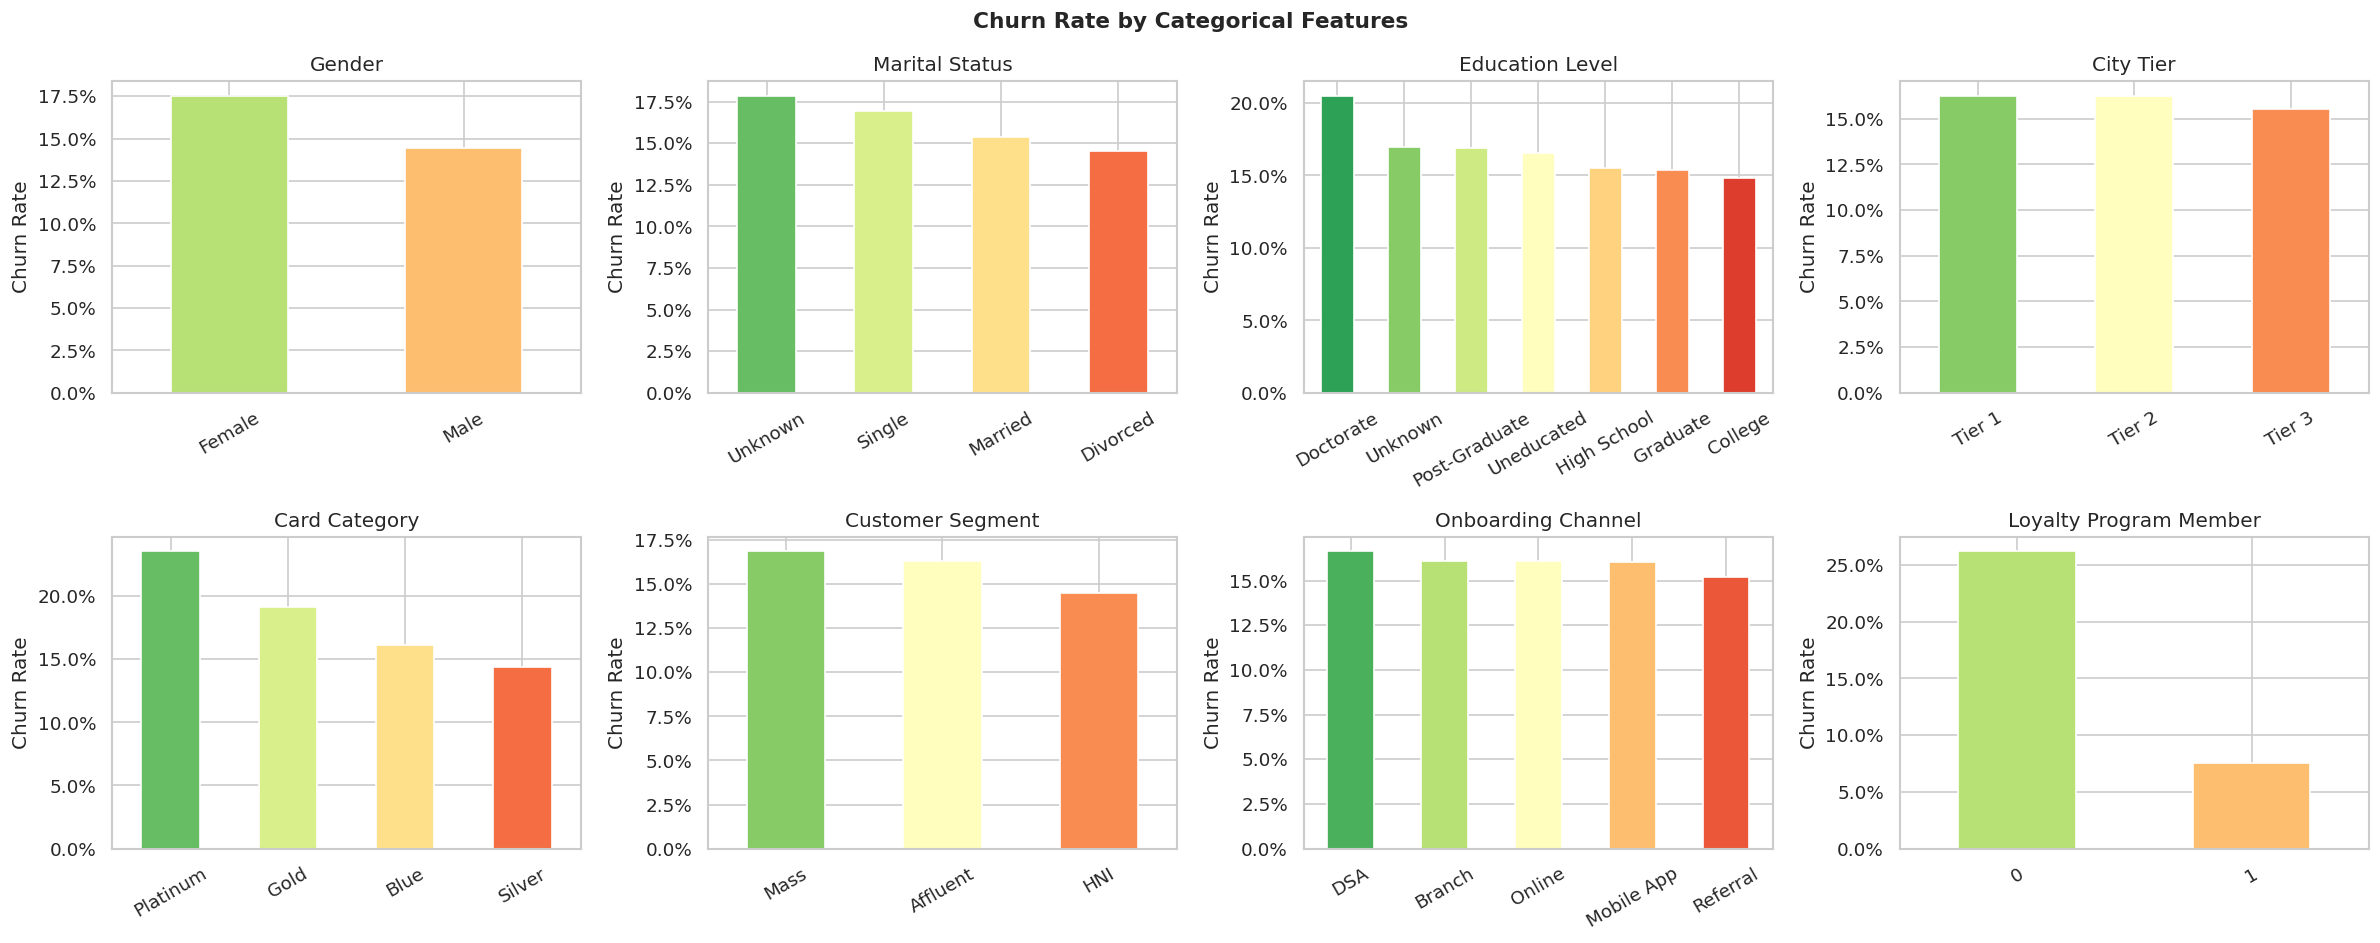

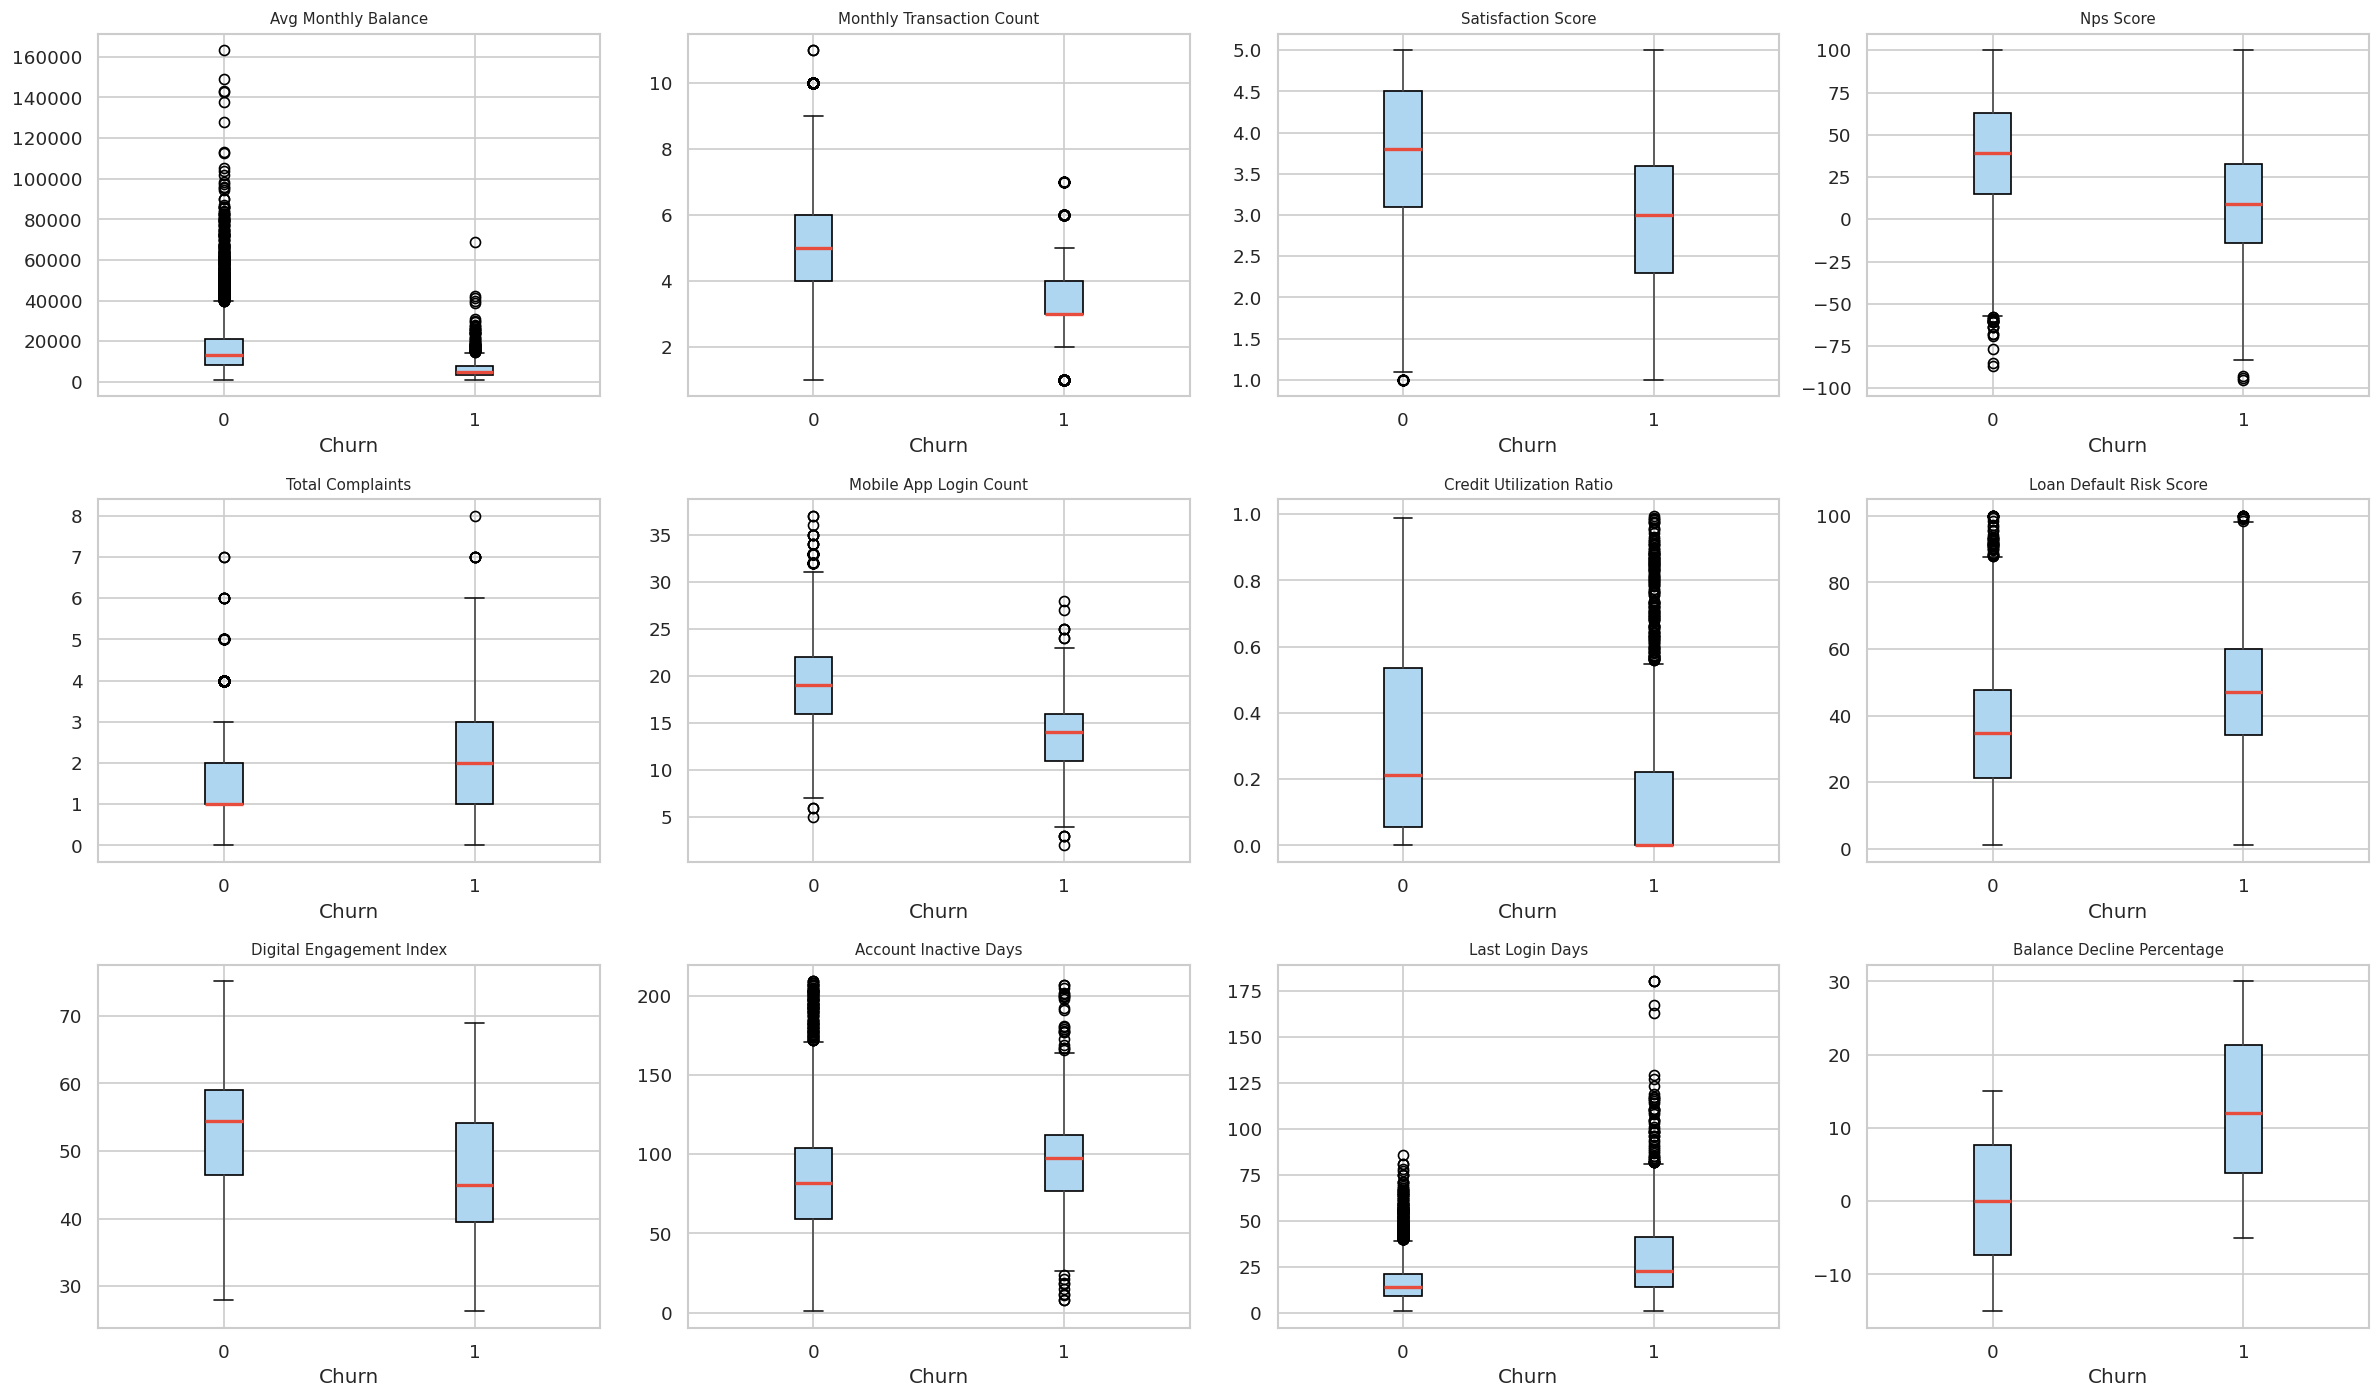

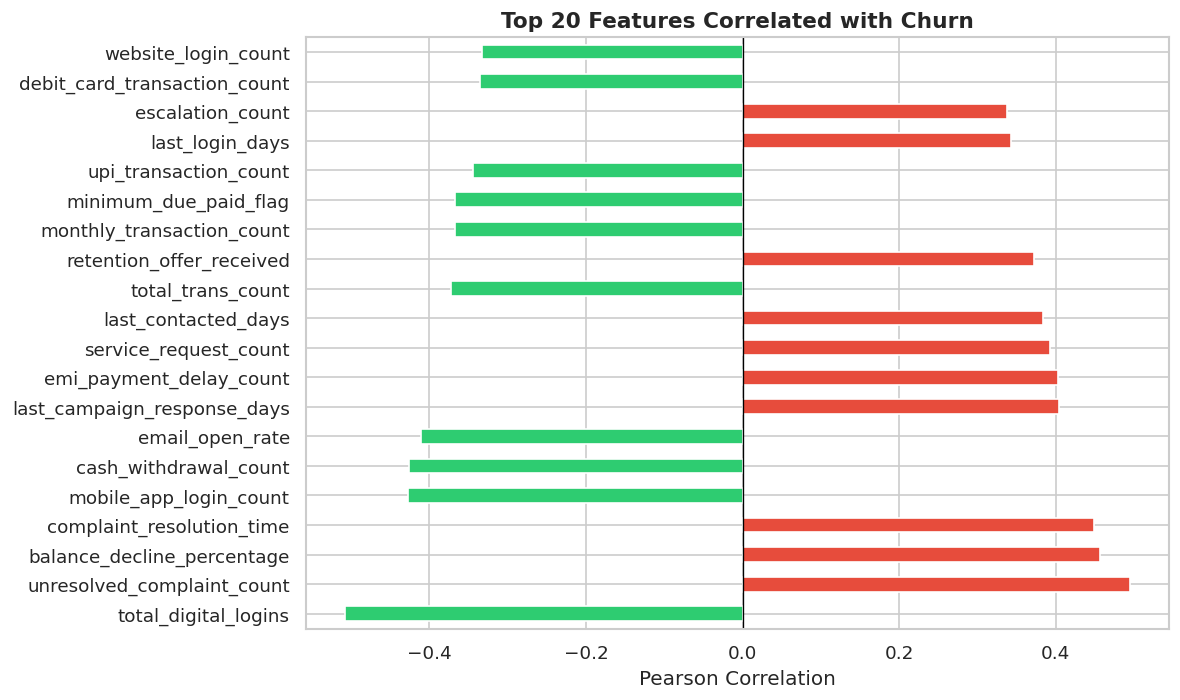


Top Positive Correlations with Churn:
unresolved_complaint_count    0.4943
balance_decline_percentage    0.4559
complaint_resolution_time     0.4483
last_campaign_response_days   0.4048
emi_payment_delay_count       0.4032
service_request_count         0.3922
last_contacted_days           0.3837
retention_offer_received      0.3720
last_login_days               0.3426
escalation_count              0.3375

Top Negative Correlations with Churn:
total_digital_logins           -0.5078
mobile_app_login_count         -0.4273
cash_withdrawal_count          -0.4258
email_open_rate                -0.4111
total_trans_count              -0.3725
monthly_transaction_count      -0.3676
minimum_due_paid_flag          -0.3671
upi_transaction_count          -0.3441
debit_card_transaction_count   -0.3348
website_login_count            -0.3326


In [8]:
# EDA PIPELINE

TARGET = "churn"

# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("RetentionFlow — EDA Overview", fontsize=14, fontweight="bold")

# Churn pie
axes[0].pie(
    churn_counts, labels=["Non-Churn", "Churn"],
    autopct="%1.1f%%", colors=["#4CAF50", "#F44336"],
    startangle=90, explode=(0, 0.05)
)
axes[0].set_title("Target Distribution")

# Age distribution by churn
df_train.groupby(TARGET)["age"].plot(
    kind="kde", ax=axes[1], legend=True
)
axes[1].set_title("Age Distribution by Churn")
axes[1].set_xlabel("Age")
axes[1].legend(["Non-Churn", "Churn"])

# Tenure distribution
df_train.groupby(TARGET)["tenure_months"].plot(
    kind="kde", ax=axes[2], legend=True
)
axes[2].set_title("Tenure Distribution by Churn")
axes[2].set_xlabel("Tenure (months)")
axes[2].legend(["Non-Churn", "Churn"])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_overview.png", bbox_inches="tight")
plt.show()


#  Churn rate by key categorical features
cat_cols_eda = [
    "gender", "marital_status", "education_level",
    "city_tier", "card_category", "customer_segment",
    "onboarding_channel", "loyalty_program_member"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Churn Rate by Categorical Features", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    if col in df_train.columns:
        churn_by_cat = df_train.groupby(col)[TARGET].mean().sort_values(ascending=False)
        churn_by_cat.plot(
            kind="bar", ax=axes[i],
            color=sns.color_palette("RdYlGn_r", len(churn_by_cat))
        )
        axes[i].set_title(col.replace("_", " ").title())
        axes[i].set_ylabel("Churn Rate")
        axes[i].set_xlabel("")
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_categorical.png", bbox_inches="tight")
plt.show()


# Key numeric correlations with churn
numeric_eda = [
    "avg_monthly_balance", "monthly_transaction_count",
    "satisfaction_score", "nps_score", "total_complaints",
    "mobile_app_login_count", "credit_utilization_ratio",
    "loan_default_risk_score", "digital_engagement_index",
    "account_inactive_days", "last_login_days", "balance_decline_percentage"
]
numeric_eda = [c for c in numeric_eda if c in df_train.columns]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle("Key Numeric Features vs Churn", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(numeric_eda):
    df_train.boxplot(
        column=col, by=TARGET,
        ax=axes[i], patch_artist=True,
        boxprops=dict(facecolor="#AED6F1"),
        medianprops=dict(color="#E74C3C", linewidth=2)
    )
    axes[i].set_title(col.replace("_", " ").title(), fontsize=9)
    axes[i].set_xlabel("Churn")

plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_numeric.png", bbox_inches="tight")
plt.show()


# Correlation heatmap
num_cols_all = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df_train[num_cols_all].corr()
churn_corr   = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
churn_corr.head(20).plot(
    kind="barh", ax=ax,
    color=["#E74C3C" if v > 0 else "#2ECC71" for v in churn_corr.head(20)]
)
ax.set_title("Top 20 Features Correlated with Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_correlation.png", bbox_inches="tight")
plt.show()

print("\nTop Positive Correlations with Churn:")
print(churn_corr[churn_corr > 0].head(10).to_string())
print("\nTop Negative Correlations with Churn:")
print(churn_corr[churn_corr < 0].head(10).to_string())

In [9]:
# DATA CLEANING


def clean_dataframe(df, is_train=True):
    """
    Cleans the dataframe:
    - Removes duplicates
    - Standardizes text columns
    - Fills missing values
    - Caps outliers
    """
    df = df.copy()

    # Drop duplicates on customer_id
    if "customer_id" in df.columns:
        before = len(df)
        df = df.drop_duplicates(subset=["customer_id"])
        print(f"   Dropped {before - len(df)} duplicate rows.")

    # Identify column types
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    # Drop target from numeric processing if train
    if is_train and TARGET in num_cols:
        num_cols.remove(TARGET)

    # Standardize text
    for col in cat_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

    # Impute numeric with median
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    # Impute categorical with mode
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Outlier capping (IQR × 1.5) on key financial cols
    cap_cols = [
        "annual_income", "avg_monthly_balance", "current_balance",
        "credit_card_limit", "credit_card_spend", "loan_outstanding_amount",
        "monthly_transaction_value", "customer_lifetime_value",
        "total_trans_amt", "avg_open_to_buy"
    ]
    for col in cap_cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    return df


print("Cleaning training data...")
df_train = clean_dataframe(df_train, is_train=True)

print("Cleaning test data...")
df_test = clean_dataframe(df_test, is_train=False)

print(f"\n Training shape after cleaning : {df_train.shape}")
print(f" Test shape after cleaning     : {df_test.shape}")

# Save cleaned copies
df_train.to_csv(f"{OUTPUT_DIR}/train_cleaned.csv", index=False)
df_test.to_csv(f"{OUTPUT_DIR}/test_cleaned.csv", index=False)
print("\n Cleaned CSVs saved.")

Cleaning training data...
   Dropped 0 duplicate rows.
Cleaning test data...
   Dropped 0 duplicate rows.

 Training shape after cleaning : (8101, 98)
 Test shape after cleaning     : (2026, 97)

 Cleaned CSVs saved.


In [10]:
# ADVANCED FEATURE ENGINEERING

def engineer_features(df):

    # keeping original dataframe safe
    df = df.copy()

    # digital engagement score
    mobile_norm = (
        df["mobile_app_login_count"]
        / (df["mobile_app_login_count"].max() + 1)
    )

    web_norm = (
        df["website_login_count"]
        / (df["website_login_count"].max() + 1)
    )

    df["composite_digital_score"] = (
        mobile_norm * 35
        + web_norm * 20
        + df["digital_transaction_ratio"] * 25
        + df["mobile_banking_active_flag"] * 10
        + df["paperless_statement_enabled"] * 10
    ).round(4)

    df["low_digital_activity"] = (
        df["composite_digital_score"] < 20
    ).astype(int)

    # financial ratios
    df["balance_to_income_ratio"] = (
        df["avg_monthly_balance"]
        / (df["annual_income"] / 12 + 1)
    ).round(4)

    df["clv_to_income_ratio"] = (
        df["customer_lifetime_value"]
        / (df["annual_income"] + 1)
    ).round(4)

    df["spend_to_limit_ratio"] = (
        df["credit_card_spend"]
        / (df["credit_card_limit"] + 1)
    ).round(4)

    df["emi_to_income_ratio"] = (
        df["emi_amount"]
        / (df["monthly_income_estimate"] + 1)
    ).round(4)

    df["transaction_to_balance_ratio"] = (
        df["monthly_transaction_value"]
        / (df["avg_monthly_balance"] + 1)
    ).round(4)

    # total banking products held
    product_flags = [
        "savings_account_flag",
        "current_account_flag",
        "credit_card_flag",
        "personal_loan_flag",
        "home_loan_flag",
        "auto_loan_flag",
        "fixed_deposit_flag",
        "investment_product_flag",
        "insurance_product_flag",
        "demat_account_flag"
    ]

    product_flags = [c for c in product_flags if c in df.columns]

    df["total_products_held"] = df[product_flags].sum(axis=1)

    df["single_product_flag"] = (
        df["total_products_held"] == 1
    ).astype(int)

    df["multi_product_flag"] = (
        df["total_products_held"] >= 3
    ).astype(int)

    df["products_per_tenure"] = (
        df["total_products_held"]
        / (df["tenure_months"] + 1)
    ).round(4)

    # complaint and service metrics
    df["complaint_resolution_ratio"] = (
        df["unresolved_complaint_count"]
        / (df["total_complaints"] + 1)
    ).round(4)

    df["high_complaint_flag"] = (
        df["total_complaints"]
        > df["total_complaints"].quantile(0.75)
    ).astype(int)

    df["escalation_rate"] = (
        df["escalation_count"]
        / (df["total_complaints"] + 1)
    ).round(4)

    df["satisfaction_nps_composite"] = (
        df["satisfaction_score"] * 0.5
        + df["nps_score"] * 0.5
    ).round(4)

    df["low_satisfaction_flag"] = (
        (df["satisfaction_score"] < 3)
        | (df["nps_score"] < 3)
    ).astype(int)

    # credit risk related features
    df["credit_risk_composite"] = (
        df["loan_default_risk_score"] * 0.4
        + df["credit_utilization_ratio"] * 0.3
        + df["late_credit_card_payment_count"] * 0.2
        + df["emi_payment_delay_count"] * 0.1
    ).round(4)

    df["financial_stress_flag"] = (
        (df["credit_utilization_ratio"] > 0.8)
        | (
            df["loan_default_risk_score"]
            > df["loan_default_risk_score"].quantile(0.85)
        )
        | (df["emi_payment_delay_count"] >= 3)
    ).astype(int)

    df["credit_utilization_trend"] = (
        df["credit_utilization_ratio"]
        - df["credit_utilization_3m_avg"]
    ).round(4)

    # transaction behaviour
    df["transaction_frequency_score"] = (
        df["monthly_transaction_count"]
        / (df["tenure_months"] + 1)
    ).round(4)

    df["upi_dominance_ratio"] = (
        df["upi_transaction_count"]
        / (df["monthly_transaction_count"] + 1)
    ).round(4)

    df["transaction_growth"] = (
        df["total_ct_chng_q4_q1"]
    )

    df["high_cash_withdrawal_flag"] = (
        df["cash_withdrawal_count"]
        > df["cash_withdrawal_count"].quantile(0.8)
    ).astype(int)

    df["zero_balance_flag"] = (
        df["avg_monthly_balance"] <= 0
    ).astype(int)

    df["balance_declining_flag"] = (
        df["balance_decline_percentage"] > 20
    ).astype(int)

    # inactivity features
    df["login_days_x_inactive"] = (
        df["last_login_days"]
        * df["account_inactive_days"]
    )

    df["dormancy_risk_flag"] = (
        (df["last_login_days"] > 30)
        & (df["account_inactive_days"] > 60)
    ).astype(int)

    df["recency_engagement_score"] = (
        1 / (df["last_login_days"] + 1)
        + 1 / (df["account_inactive_days"] + 1)
        + 1 / (df["last_contacted_days"] + 1)
    ).round(6)

    # marketing response features
    df["campaign_response_rate"] = (
        df["campaign_response_count"]
        / (df["campaign_received_count"] + 1)
    ).round(4)

    df["retention_offer_response"] = (
        df["retention_offer_accepted"]
        / (df["retention_offer_received"] + 1)
    ).round(4)

    # converting aware / not aware into numeric
    df["competitor_aware_flag"] = (
        df["competitor_bank_offer_awareness"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "aware": 1,
            "not aware": 0
        })
        .fillna(0)
        .astype(int)
    )

    # normalization helper
    def min_max_norm(s):

        mn = s.min()
        mx = s.max()

        return (
            (s - mn)
            / (mx - mn + 1e-9)
        )

    # customer value score
    df["customer_value"] = (
        min_max_norm(df["customer_lifetime_value"]) * 0.4
        + min_max_norm(df["annual_income"]) * 0.25
        + min_max_norm(df["avg_monthly_balance"]) * 0.2
        + min_max_norm(df["total_products_held"]) * 0.15
    ).round(4)

    # wealth segmentation
    df["wealth_tier"] = pd.cut(
        df["customer_value"],
        bins=[0, 0.25, 0.50, 0.75, 1.01],
        labels=[
            "Basic",
            "Standard",
            "Premium",
            "Elite"
        ]
    ).astype(str)

    # interaction features
    df["age_tenure_interaction"] = (
        df["age"] * df["tenure_months"]
    )

    df["income_products_interaction"] = (
        df["annual_income"]
        * df["total_products_held"]
    )

    df["complaints_x_inactivity"] = (
        df["total_complaints"]
        * df["account_inactive_days"]
    )

    df["digital_x_balance"] = (
        df["composite_digital_score"]
        * df["avg_monthly_balance"]
    )

    df["satisfaction_x_tenure"] = (
        df["satisfaction_score"]
        * df["tenure_months"]
    )

    # rfm scoring
    df["rfm_recency"] = min_max_norm(
        1 / (df["account_inactive_days"] + 1)
    )

    df["rfm_frequency"] = min_max_norm(
        df["monthly_transaction_count"]
    )

    df["rfm_monetary"] = min_max_norm(
        df["monthly_transaction_value"]
    )

    df["rfm_score"] = (
        df["rfm_recency"] * 0.35
        + df["rfm_frequency"] * 0.35
        + df["rfm_monetary"] * 0.30
    ).round(4)

    # log transform for skewed columns
    for col in [
        "annual_income",
        "customer_lifetime_value",
        "avg_monthly_balance",
        "total_trans_amt",
        "loan_outstanding_amount"
    ]:

        if col in df.columns:

            df[f"log_{col}"] = np.log1p(
                df[col].clip(lower=0)
            )

    return df


print("Engineering features on training set...")
df_train = engineer_features(df_train)

print("Engineering features on test set...")
df_test = engineer_features(df_test)

new_cols = df_train.shape[1] - 98

print(f"\nFeature engineering complete.")
print(f"Training shape : {df_train.shape}")
print(f"New features created : ~{new_cols}")

print("\nNew feature groups:")

for g in [
    "composite_digital_score",
    "balance_to_income_ratio",
    "total_products_held",
    "complaint_resolution_ratio",
    "credit_risk_composite",
    "rfm_score",
    "customer_value",
    "dormancy_risk_flag",
    "campaign_response_rate",
    "financial_stress_flag"
]:
    if g in df_train.columns:
        print(f"✓ {g}")

Engineering features on training set...
Engineering features on test set...

Feature engineering complete.
Training shape : (8101, 145)
New features created : ~47

New feature groups:
✓ composite_digital_score
✓ balance_to_income_ratio
✓ total_products_held
✓ complaint_resolution_ratio
✓ credit_risk_composite
✓ rfm_score
✓ customer_value
✓ dormancy_risk_flag
✓ campaign_response_rate
✓ financial_stress_flag


In [11]:
# ENCODE CATEGORICALS & TRAIN/VAL SPLIT


# Store customer_ids before encoding
train_ids = df_train["customer_id"].copy()
test_ids  = df_test["customer_id"].copy()

# Drop ID column
df_train_enc = df_train.drop(columns=["customer_id"])
df_test_enc  = df_test.drop(columns=["customer_id"])

# Label encode all remaining object columns
cat_cols_enc = df_train_enc.select_dtypes(include=["object"]).columns.tolist()

le_dict = {}
for col in cat_cols_enc:
    le = LabelEncoder()
    # Fit on combined unique values to avoid unseen labels
    combined = pd.concat([
        df_train_enc[col],
        df_test_enc[col] if col in df_test_enc.columns else pd.Series([])
    ]).astype(str).unique()
    le.fit(combined)
    df_train_enc[col] = le.transform(df_train_enc[col].astype(str))
    if col in df_test_enc.columns:
        df_test_enc[col] = le.transform(df_test_enc[col].astype(str))
    le_dict[col] = le

print(f"Encoded {len(cat_cols_enc)} categorical columns: {cat_cols_enc}")

# Separate features & target
X = df_train_enc.drop(columns=[TARGET])
y = df_train_enc[TARGET]
X_submission = df_test_enc.copy()

# Align test columns to training (add missing as 0)
for col in X.columns:
    if col not in X_submission.columns:
        X_submission[col] = 0
X_submission = X_submission[X.columns]

# Stratified train/validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"\n Split complete:")
print(f"   X_train : {X_train.shape}  |  Churn rate: {y_train.mean():.2%}")
print(f"   X_val   : {X_val.shape}  |  Churn rate: {y_val.mean():.2%}")
print(f"   X_submit: {X_submission.shape}")
print(f"   Features: {X_train.shape[1]}")

Encoded 16 categorical columns: ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment', 'wealth_tier']

 Split complete:
   X_train : (6480, 143)  |  Churn rate: 16.06%
   X_val   : (1621, 143)  |  Churn rate: 16.10%
   X_submit: (2026, 143)
   Features: 143


In [12]:
# CLASS IMBALANCE HANDLING WITH SMOTE-TOMEK


print(f"Before resampling — Class distribution:")
print(f"   Non-churn: {(y_train==0).sum():,}")
print(f"   Churn    : {(y_train==1).sum():,}")

# SMOTETomek: oversample minority + remove Tomek links (borderline)
smote_tomek = SMOTETomek(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE-Tomek resampling:")
print(f"   Non-churn: {(y_train_res==0).sum():,}")
print(f"   Churn    : {(y_train_res==1).sum():,}")
print(f"   Total    : {len(y_train_res):,}")

# Scale for Logistic Regression
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled   = scaler.transform(X_val)
X_sub_scaled   = scaler.transform(X_submission)

print("\n Scaling complete (RobustScaler).")

Before resampling — Class distribution:
   Non-churn: 5,439
   Churn    : 1,041

After SMOTE-Tomek resampling:
   Non-churn: 5,362
   Churn    : 5,362
   Total    : 10,724

 Scaling complete (RobustScaler).


In [13]:
# MODEL COMPARISON
# XGBoost | LightGBM | CatBoost | RF | GBM | Logistic


print("=" * 65)
print(" RETENTIONFLOW — MODEL COMPARISON")
print("=" * 65)

scale_pos = int((y_train_res == 0).sum() / (y_train_res == 1).sum())

models = {
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        use_label_encoder=False,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_seed=RANDOM_STATE,
        verbose=0
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    "LogisticRegression": LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n  Training {name}...", end="")

    # Use scaled data for LR, unscaled for tree models
    if name == "LogisticRegression":
        X_tr, X_v = X_train_scaled, X_val_scaled
    else:
        X_tr, X_v = X_train_res, X_val

    model.fit(X_tr, y_train_res)
    y_prob = model.predict_proba(X_v)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    pr_auc = average_precision_score(y_val, y_prob)
    roc    = roc_auc_score(y_val, y_prob)
    f1     = f1_score(y_val, y_pred)
    prec   = precision_score(y_val, y_pred, zero_division=0)
    rec    = recall_score(y_val, y_pred)

    # Business cost @ default 0.5 threshold
    cm      = confusion_matrix(y_val, y_pred)
    fn      = cm[1][0]
    fp      = cm[0][1]
    biz_cost = fn * FN_COST + fp * FP_COST

    results[name] = {
        "PR_AUC": pr_auc, "ROC_AUC": roc,
        "F1": f1, "Precision": prec, "Recall": rec,
        "FN": fn, "FP": fp, "Biz_Cost_INR": biz_cost
    }
    trained_models[name] = model
    print(f"  PR-AUC={pr_auc:.4f}  F1={f1:.4f}  BizCost=₹{biz_cost:,.0f}")

results_df = pd.DataFrame(results).T.sort_values("PR_AUC", ascending=False)

print("\n" + "=" * 65)
print(" MODEL COMPARISON RESULTS")
print("=" * 65)
print(results_df.to_string())

BEST_MODEL_NAME = results_df.index[0]
print(f"\n Best Model: {BEST_MODEL_NAME}  (PR-AUC = {results_df.iloc[0]['PR_AUC']:.4f})")

 RETENTIONFLOW — MODEL COMPARISON

  Training XGBoost...  PR-AUC=0.9998  F1=0.9923  BizCost=₹160,000

  Training LightGBM...  PR-AUC=0.9999  F1=0.9903  BizCost=₹200,000

  Training CatBoost...  PR-AUC=1.0000  F1=0.9981  BizCost=₹40,000

  Training RandomForest...  PR-AUC=0.9989  F1=0.9864  BizCost=₹280,000

  Training GradientBoosting...  PR-AUC=0.9999  F1=0.9903  BizCost=₹200,000

  Training LogisticRegression...  PR-AUC=0.9996  F1=0.9962  BizCost=₹80,000

 MODEL COMPARISON RESULTS
                    PR_AUC  ROC_AUC     F1  Precision  Recall     FN     FP  Biz_Cost_INR
CatBoost            1.0000   1.0000 0.9981     1.0000  0.9962 1.0000 0.0000    40000.0000
GradientBoosting    0.9999   1.0000 0.9903     1.0000  0.9808 5.0000 0.0000   200000.0000
LightGBM            0.9999   1.0000 0.9903     1.0000  0.9808 5.0000 0.0000   200000.0000
XGBoost             0.9998   1.0000 0.9923     1.0000  0.9847 4.0000 0.0000   160000.0000
LogisticRegression  0.9996   0.9999 0.9962     1.0000  0.9923 

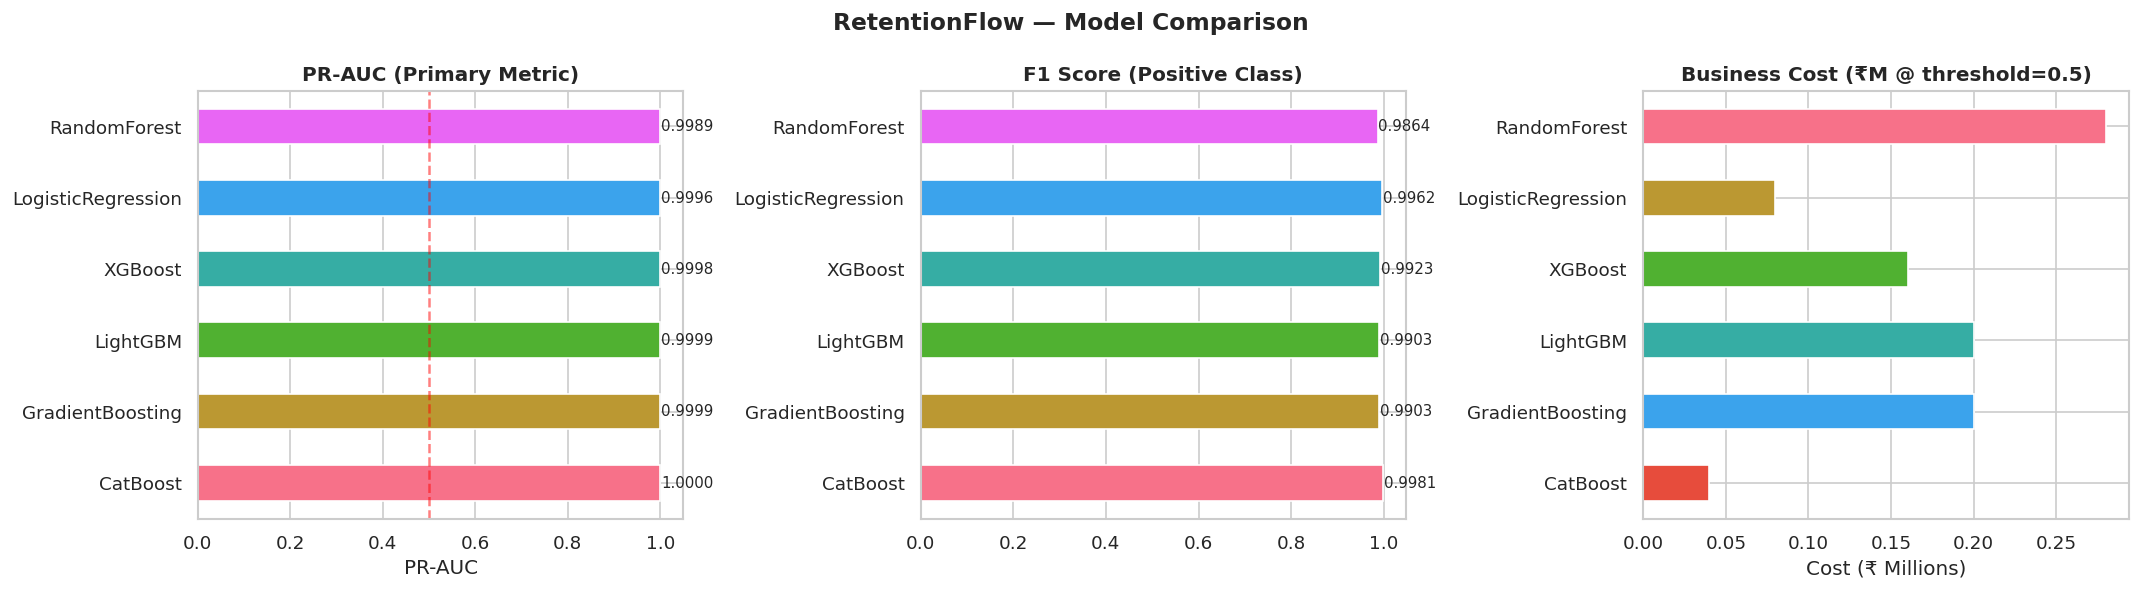

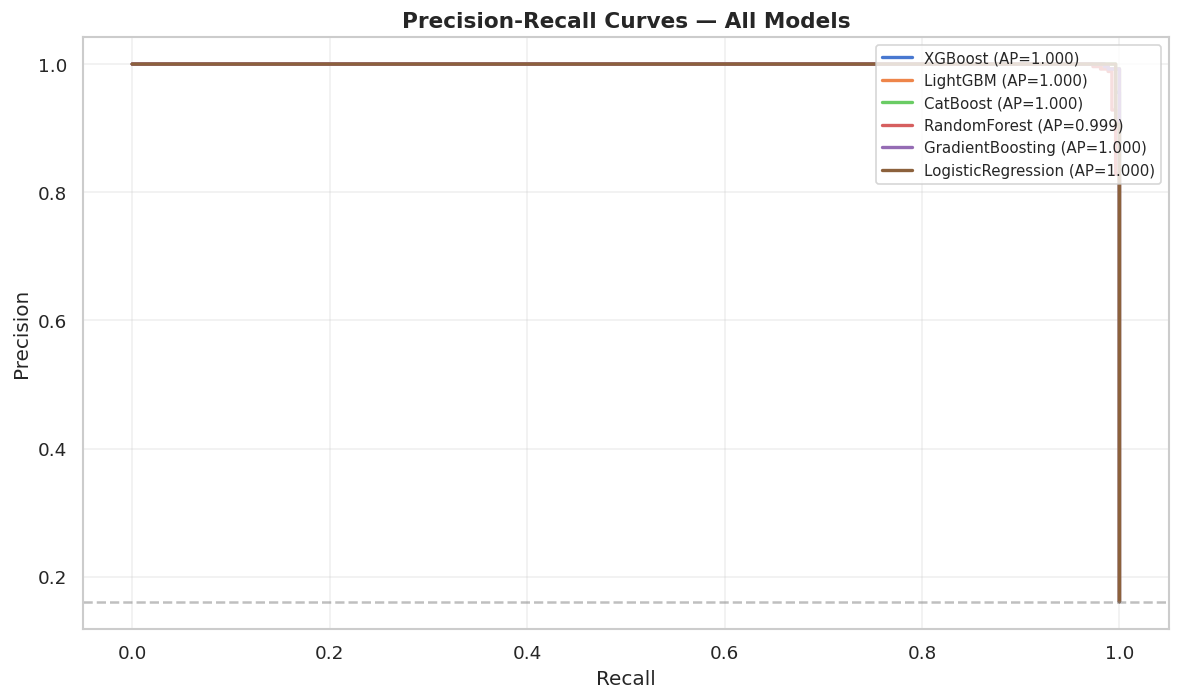

In [14]:
# MODEL COMPARISON CHARTS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RetentionFlow — Model Comparison", fontsize=14, fontweight="bold")

colors = sns.color_palette("husl", len(results_df))

# PR-AUC
results_df["PR_AUC"].plot(
    kind="barh", ax=axes[0], color=colors
)
axes[0].set_title("PR-AUC (Primary Metric)", fontweight="bold")
axes[0].set_xlabel("PR-AUC")
axes[0].axvline(0.5, color="red", linestyle="--", alpha=0.5, label="Baseline")
for i, v in enumerate(results_df["PR_AUC"]):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# F1 Score
results_df["F1"].plot(
    kind="barh", ax=axes[1], color=colors
)
axes[1].set_title("F1 Score (Positive Class)", fontweight="bold")
for i, v in enumerate(results_df["F1"]):
    axes[1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# Business Cost
(results_df["Biz_Cost_INR"] / 1_000_000).plot(
    kind="barh", ax=axes[2], color=["#E74C3C" if i == 0 else c for i, c in enumerate(colors[::-1])]
)
axes[2].set_title("Business Cost (₹M @ threshold=0.5)", fontweight="bold")
axes[2].set_xlabel("Cost (₹ Millions)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", bbox_inches="tight")
plt.show()


# PR Curves for all models
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Precision-Recall Curves — All Models", fontsize=13, fontweight="bold")

for i, (name, model) in enumerate(trained_models.items()):
    X_v = X_val_scaled if name == "LogisticRegression" else X_val
    y_prob = model.predict_proba(X_v)[:, 1]
    prec_arr, rec_arr, _ = precision_recall_curve(y_val, y_prob)
    pr_auc_val = average_precision_score(y_val, y_prob)
    ax.plot(rec_arr, prec_arr, label=f"{name} (AP={pr_auc_val:.3f})", linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right", fontsize=9)
ax.axhline(y_val.mean(), color="gray", linestyle="--", alpha=0.5, label="Baseline")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curves.png", bbox_inches="tight")
plt.show()

 BUSINESS COST THRESHOLD OPTIMIZATION
 Model            : CatBoost
 Optimal Threshold: 0.44
 Minimum Biz Cost : ₹40,000
 Cost at 0.5      : ₹40,000

 Confusion Matrix at threshold=0.44:
   TN=1,360  FP=0
   FN=1  TP=260

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1360
           1       1.00      1.00      1.00       261

    accuracy                           1.00      1621
   macro avg       1.00      1.00      1.00      1621
weighted avg       1.00      1.00      1.00      1621



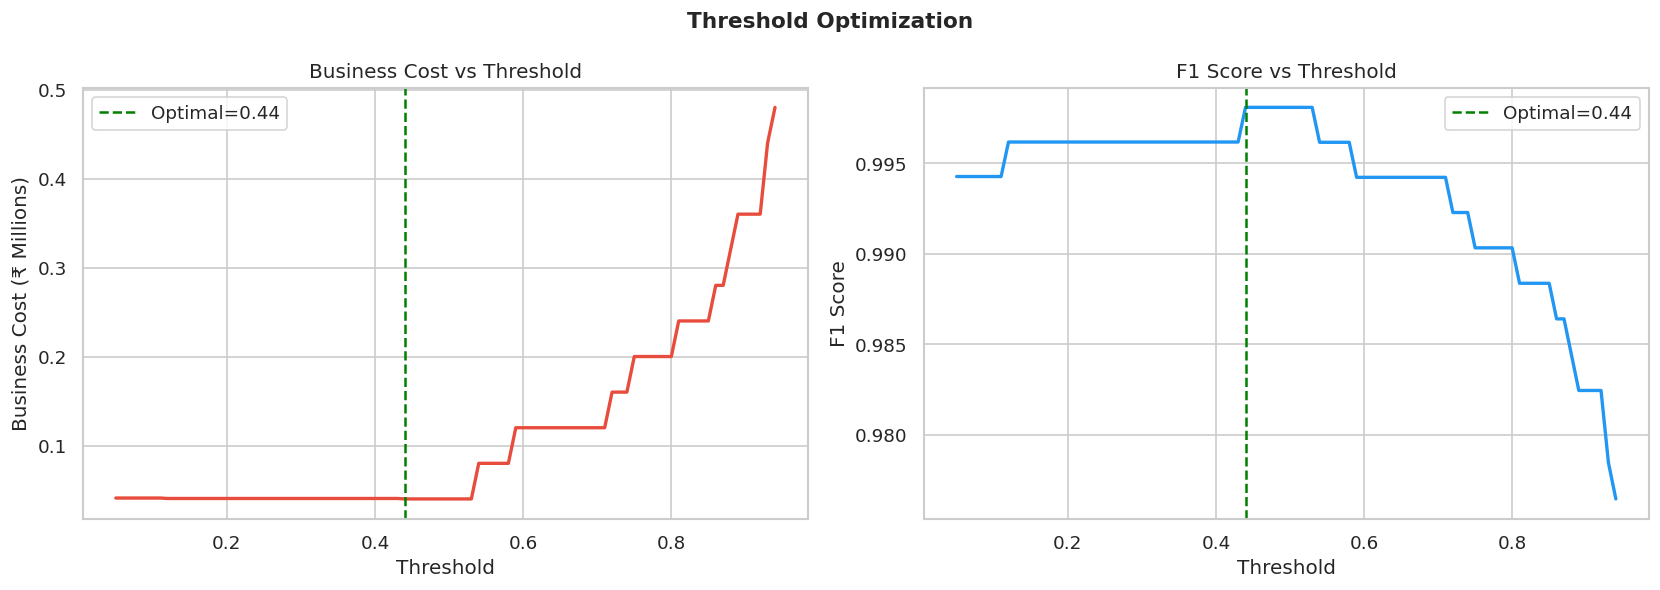

In [15]:
# THRESHOLD OPTIMIZATION FOR BUSINESS COST
# FN = ₹40,000 | FP = ₹500


best_model = trained_models[BEST_MODEL_NAME]
X_v_best   = X_val_scaled if BEST_MODEL_NAME == "LogisticRegression" else X_val
y_prob_best = best_model.predict_proba(X_v_best)[:, 1]

thresholds  = np.arange(0.05, 0.95, 0.01)
biz_costs   = []
f1_scores   = []
pr_aucs_at  = []

for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    cm_t     = confusion_matrix(y_val, y_pred_t)
    fn_t     = cm_t[1][0]
    fp_t     = cm_t[0][1]
    cost_t   = fn_t * FN_COST + fp_t * FP_COST
    f1_t     = f1_score(y_val, y_pred_t, zero_division=0)
    biz_costs.append(cost_t)
    f1_scores.append(f1_t)

# Optimal threshold = minimize business cost
opt_idx    = np.argmin(biz_costs)
BEST_THRESHOLD = thresholds[opt_idx]
opt_cost   = biz_costs[opt_idx]

print("=" * 60)
print(" BUSINESS COST THRESHOLD OPTIMIZATION")
print("=" * 60)
print(f" Model            : {BEST_MODEL_NAME}")
print(f" Optimal Threshold: {BEST_THRESHOLD:.2f}")
print(f" Minimum Biz Cost : ₹{opt_cost:,.0f}")
print(f" Cost at 0.5      : ₹{biz_costs[np.argmin(np.abs(thresholds - 0.5))]:,.0f}")

# Final predictions at optimal threshold
y_pred_opt = (y_prob_best >= BEST_THRESHOLD).astype(int)
cm_opt     = confusion_matrix(y_val, y_pred_opt)

print(f"\n Confusion Matrix at threshold={BEST_THRESHOLD:.2f}:")
print(f"   TN={cm_opt[0][0]:,}  FP={cm_opt[0][1]:,}")
print(f"   FN={cm_opt[1][0]:,}  TP={cm_opt[1][1]:,}")
print(f"\n{classification_report(y_val, y_pred_opt)}")


# Plot threshold vs cost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Threshold Optimization", fontsize=13, fontweight="bold")

axes[0].plot(thresholds, [c / 1e6 for c in biz_costs], color="#E74C3C", linewidth=2)
axes[0].axvline(BEST_THRESHOLD, color="green", linestyle="--", label=f"Optimal={BEST_THRESHOLD:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Business Cost (₹ Millions)")
axes[0].set_title("Business Cost vs Threshold")
axes[0].legend()

axes[1].plot(thresholds, f1_scores, color="#2196F3", linewidth=2)
axes[1].axvline(BEST_THRESHOLD, color="green", linestyle="--", label=f"Optimal={BEST_THRESHOLD:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/threshold_optimization.png", bbox_inches="tight")
plt.show()

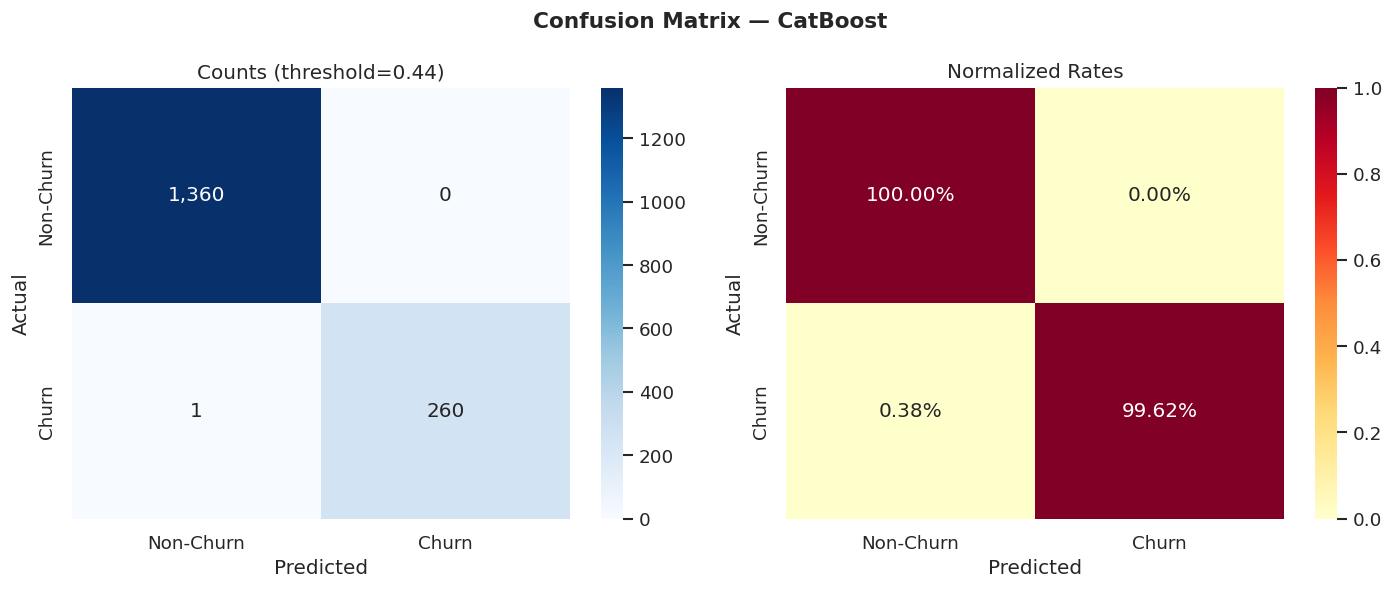


 Business Cost Breakdown:
  False Negatives  : 1 × ₹40,000 = ₹40,000
  False Positives  : 0 × ₹500 = ₹0
  TOTAL COST       : ₹40,000


In [16]:
# CONFUSION MATRIX VISUALIZATION


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Confusion Matrix — {BEST_MODEL_NAME}", fontsize=13, fontweight="bold")

# Raw counts
sns.heatmap(
    cm_opt, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Non-Churn", "Churn"],
    yticklabels=["Non-Churn", "Churn"],
    ax=axes[0]
)
axes[0].set_title(f"Counts (threshold={BEST_THRESHOLD:.2f})")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Normalized
cm_norm = cm_opt.astype(float) / cm_opt.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2%", cmap="YlOrRd",
    xticklabels=["Non-Churn", "Churn"],
    yticklabels=["Non-Churn", "Churn"],
    ax=axes[1]
)
axes[1].set_title("Normalized Rates")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", bbox_inches="tight")
plt.show()

# Business cost breakdown
tn, fp_val, fn_val, tp_val = cm_opt.ravel()
print("\n Business Cost Breakdown:")
print(f"  False Negatives  : {fn_val:,} × ₹{FN_COST:,} = ₹{fn_val * FN_COST:,.0f}")
print(f"  False Positives  : {fp_val:,} × ₹{FP_COST:,} = ₹{fp_val * FP_COST:,.0f}")
print(f"  TOTAL COST       : ₹{fn_val * FN_COST + fp_val * FP_COST:,.0f}")

Computing SHAP values...
  SHAP shape: (300, 143)

 Top 20 Features by SHAP Importance:
                               feature  mean_abs_shap
                   clv_to_income_ratio         1.5173
                  total_digital_logins         0.8636
                 cash_withdrawal_count         0.8578
           customer_feedback_sentiment         0.6932
                 minimum_due_paid_flag         0.6388
relationship_manager_interaction_count         0.6301
            balance_decline_percentage         0.6069
                        referral_count         0.5958
                     digital_x_balance         0.5917
            complaint_resolution_ratio         0.5765
             monthly_transaction_count         0.5717
                    branch_visit_count         0.4636
                       email_open_rate         0.4338
                     total_trans_count         0.3794
                   total_revolving_bal         0.3531
          debit_card_transaction_count         0

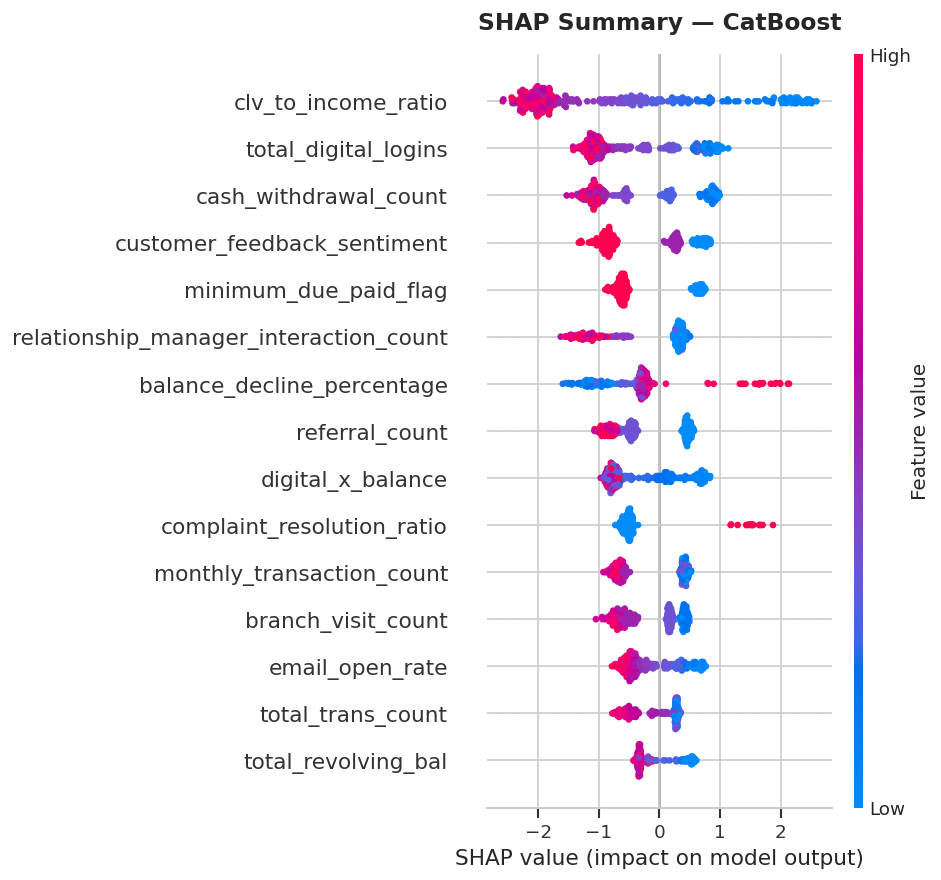

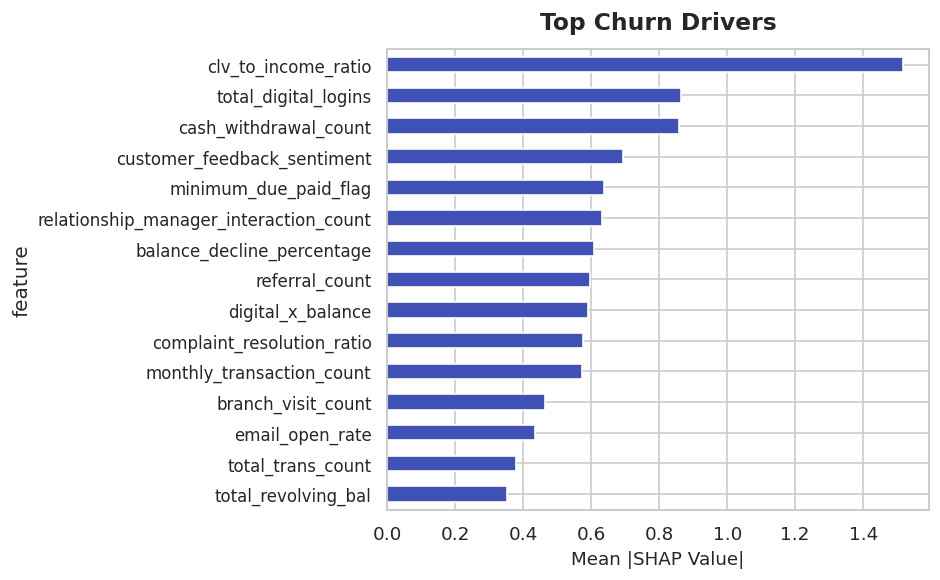


 SHAP Waterfall — Most At-Risk Customer (sample index 229):


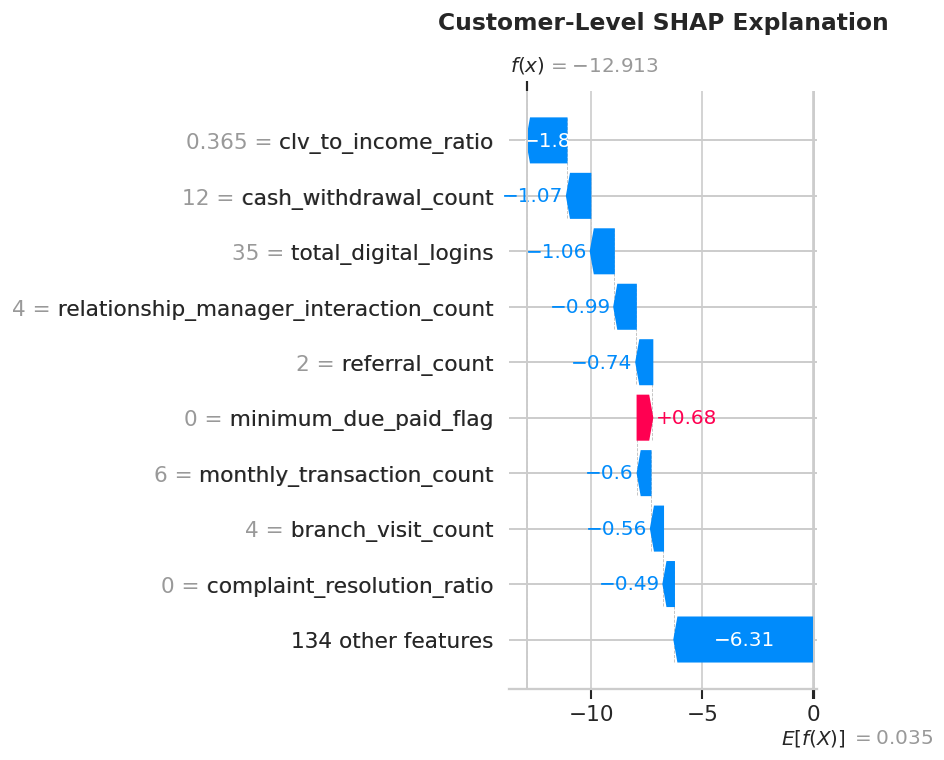


 Top SHAP features stored for recommendation engine: 30 features


In [17]:
# SHAP EXPLAINABILITY
# Global feature importance + individual explanations


print("Computing SHAP values...")

# Use a sample for speed
SHAP_SAMPLE = min(300, len(X_val))

X_shap = X_val.sample(
    SHAP_SAMPLE,
    random_state=RANDOM_STATE
)

# SHAP explainer (TreeExplainer for tree models)
if BEST_MODEL_NAME in ["XGBoost", "LightGBM", "CatBoost", "RandomForest", "GradientBoosting"]:

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_shap)

    # For binary classification, some models return list
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

else:

    explainer = shap.LinearExplainer(
        best_model,
        X_train_scaled[:SHAP_SAMPLE]
    )

    shap_vals = explainer.shap_values(
        X_val_scaled[:SHAP_SAMPLE]
    )

print(f"  SHAP shape: {shap_vals.shape}")

# Global feature importance (mean |SHAP|)
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": np.abs(shap_vals).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("\n Top 20 Features by SHAP Importance:")

print(
    shap_importance.head(20).to_string(index=False)
)

# SHAP Summary Plot
plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_vals,
    X_shap,
    max_display=15,
    show=False,
    plot_type="dot"
)

plt.title(
    f"SHAP Summary — {BEST_MODEL_NAME}",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/shap_summary.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

# SHAP Bar plot (top 20)
fig, ax = plt.subplots(figsize=(8, 5))

shap_importance.head(15).set_index("feature")[
    "mean_abs_shap"
].plot(
    kind="barh",
    ax=ax,
    color="#3F51B5"
)

ax.set_title(
    "Top Churn Drivers",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Mean |SHAP Value|",
    fontsize=11
)

ax.tick_params(axis="y", labelsize=10)

ax.invert_yaxis()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/shap_bar.png",
    bbox_inches="tight"
)

plt.show()

# Individual waterfall for the top churn-risk customer

top_idx = np.argmax(
    y_prob_best[:len(shap_vals)]
)

print(
    f"\n SHAP Waterfall — Most At-Risk Customer "
    f"(sample index {top_idx}):"
)

base_value = explainer.expected_value

if isinstance(base_value, list):
    base_value = base_value[1]

plt.figure(figsize=(10, 5))

shap.plots.waterfall(

    shap.Explanation(

        values=shap_vals[top_idx],

        base_values=base_value,

        data=X_shap.iloc[top_idx],

        feature_names=X_shap.columns

    ),

    max_display=10,

    show=False
)

plt.title(
    "Customer-Level SHAP Explanation",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/shap_waterfall.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

# Save feature names and SHAP importance for recommendation engine
TOP_SHAP_FEATURES = (
    shap_importance["feature"]
    .head(30)
    .tolist()
)

print(
    f"\n Top SHAP features stored for recommendation engine: "
    f"{len(TOP_SHAP_FEATURES)} features"
)

 CHURN RISK SCORING SUMMARY
risk_tier
Low         6799
Critical    1297
High           3
Medium         2

 Total predicted churners : 1,301
 Predicted churn rate     : 16.06%
 Average churn probability: 0.1606


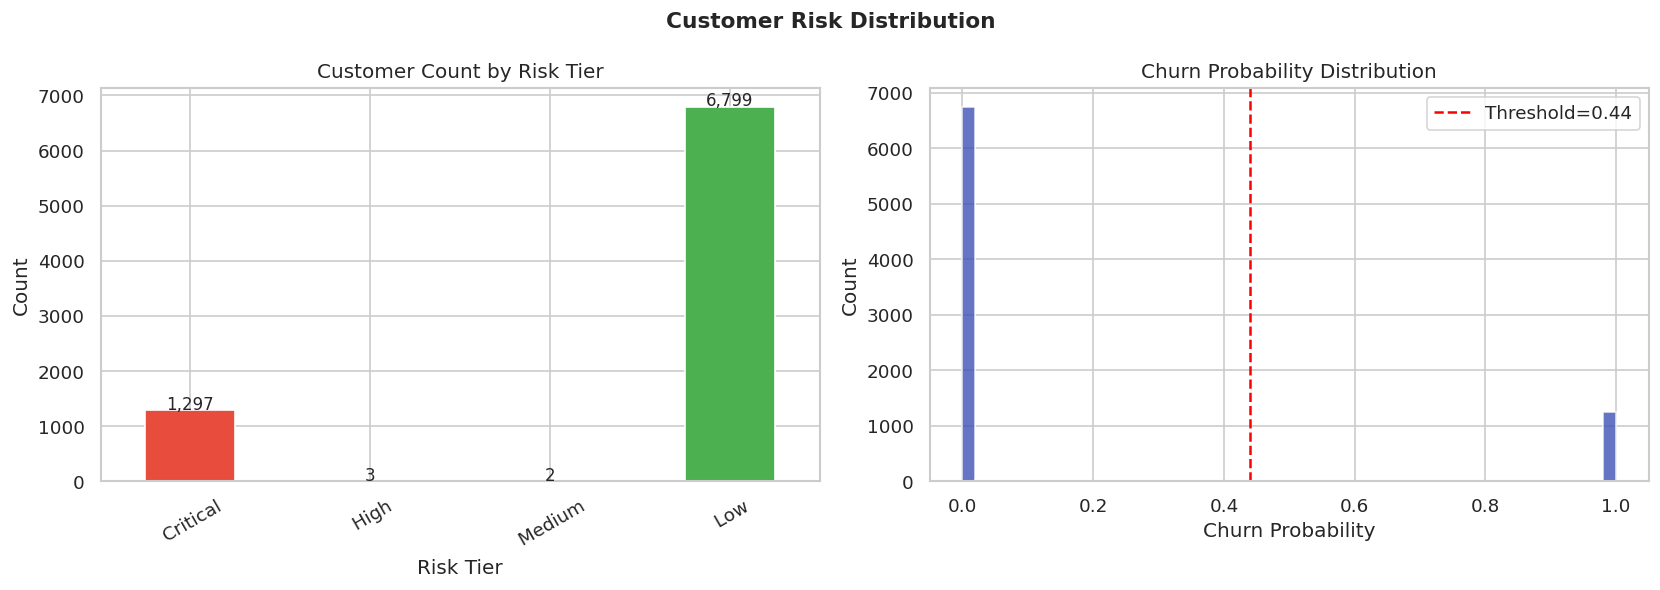


 TOP 20 HIGH-PRIORITY CUSTOMERS TO RETAIN
 customer_id  churn_probability risk_tier  priority_score  customer_value wealth_tier  annual_income  avg_monthly_balance
      138226             0.9972  Critical          0.8152          0.8175       Elite    144555.5000           19565.0000
      134471             0.9895  Critical          0.7506          0.7586       Elite    144555.5000            5651.0000
      133242             0.9959  Critical          0.7473          0.7504       Elite    142584.0000            4927.0000
      134736             0.9898  Critical          0.7402          0.7478     Premium    143150.0000            7245.0000
      135190             0.9987  Critical          0.7397          0.7407     Premium    144555.5000            7882.0000
      137061             0.9908  Critical          0.7383          0.7452     Premium    144555.5000            3175.0000
      136273             0.9991  Critical          0.7368          0.7375     Premium    144555.5000   

In [18]:
# CHURN RISK SCORING & CUSTOMER PRIORITIZATION

#  Get predictions on full training set (self-score for insights)
X_all = df_train.drop(columns=["customer_id", TARGET])
# Re-encode for scoring
X_all_enc = X_all.copy()
for col in cat_cols_enc:
    if col in X_all_enc.columns:
        X_all_enc[col] = X_all_enc[col].astype(str)
        known_classes   = list(le_dict[col].classes_)
        X_all_enc[col]  = X_all_enc[col].apply(
            lambda x: x if x in known_classes else known_classes[0]
        )
        X_all_enc[col] = le_dict[col].transform(X_all_enc[col])

# Align columns
for col in X.columns:
    if col not in X_all_enc.columns:
        X_all_enc[col] = 0
X_all_enc = X_all_enc[X.columns]

# Score
X_score = X_val_scaled if BEST_MODEL_NAME == "LogisticRegression" else X_all_enc
churn_prob_all = best_model.predict_proba(X_all_enc)[:, 1]
churn_pred_all = (churn_prob_all >= BEST_THRESHOLD).astype(int)

#  Build scoring dataframe
scoring_df = df_train[["customer_id"]].copy()
scoring_df["churn_probability"] = churn_prob_all.round(4)
scoring_df["churn_prediction"]  = churn_pred_all
scoring_df["actual_churn"]      = df_train[TARGET].values

# Bring in key features
for col in ["customer_value", "annual_income", "customer_lifetime_value",
            "avg_monthly_balance", "satisfaction_score", "total_complaints",
            "composite_digital_score", "rfm_score", "total_products_held",
            "zero_balance_flag", "single_product_flag", "financial_stress_flag",
            "low_digital_activity", "wealth_tier", "dormancy_risk_flag",
            "credit_risk_composite", "high_complaint_flag", "tenure_months",
            "age", "gender", "nps_score", "competitor_aware_flag",
            "escalation_count", "account_inactive_days", "last_login_days"]:
    if col in df_train.columns:
        scoring_df[col] = df_train[col].values

#  CHURN RISK TIER
def assign_risk_tier(prob):
    if prob >= 0.75:   return " Critical"
    elif prob >= 0.55: return " High"
    elif prob >= 0.35: return " Medium"
    else:              return " Low"

scoring_df["risk_tier"] = scoring_df["churn_probability"].apply(assign_risk_tier)

#  PRIORITY SCORE = churn_prob × customer_value (save high-value churners first)
scoring_df["priority_score"] = (
    scoring_df["churn_probability"]
    * scoring_df["customer_value"]
).round(4)

# Risk tier distribution
risk_summary = scoring_df["risk_tier"].value_counts()
print("=" * 60)
print(" CHURN RISK SCORING SUMMARY")
print("=" * 60)
print(risk_summary.to_string())
print(f"\n Total predicted churners : {churn_pred_all.sum():,}")
print(f" Predicted churn rate     : {churn_pred_all.mean():.2%}")
print(f" Average churn probability: {churn_prob_all.mean():.4f}")


# Risk tier chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Customer Risk Distribution", fontsize=13, fontweight="bold")

risk_order  = [" Critical", " High", " Medium", " Low"]
risk_counts = scoring_df["risk_tier"].value_counts().reindex(risk_order).fillna(0)
risk_colors = ["#E74C3C", "#FF9800", "#FFC107", "#4CAF50"]

risk_counts.plot(
    kind="bar", ax=axes[0], color=risk_colors, edgecolor="white"
)
axes[0].set_title("Customer Count by Risk Tier")
axes[0].set_xlabel("Risk Tier")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(risk_counts):
    axes[0].text(i, v + 10, f"{int(v):,}", ha="center", fontsize=10)

# Churn probability distribution
axes[1].hist(
    scoring_df["churn_probability"], bins=50,
    color="#3F51B5", edgecolor="white", alpha=0.8
)
axes[1].axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Threshold={BEST_THRESHOLD:.2f}")
axes[1].set_title("Churn Probability Distribution")
axes[1].set_xlabel("Churn Probability")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/risk_distribution.png", bbox_inches="tight")
plt.show()


# TOP 20 CUSTOMERS TO SAVE
top20 = scoring_df.nlargest(20, "priority_score")[[
    "customer_id", "churn_probability", "risk_tier",
    "priority_score", "customer_value", "wealth_tier",
    "annual_income", "avg_monthly_balance"
]]
print("\n" + "=" * 60)
print(" TOP 20 HIGH-PRIORITY CUSTOMERS TO RETAIN")
print("=" * 60)
print(top20.to_string(index=False))

 RECOVERABLE REVENUE ESTIMATION

 Predicted Churners       : 1,301
 Total Revenue at Risk    : ₹1,458,225
 Recoverable Revenue      : ₹437,458
 Retention Spend          : ₹650,500
 NET BENEFIT              : ₹-213,042
 ROI on Retention         : -0.3x

 Revenue by Wealth Tier:
             revenue_at_risk  recoverable_revenue
wealth_tier                                      
Standard         682622.0000          204777.0000
Basic            519020.0000          155703.0000
Premium          240110.0000           72036.0000
Elite             16473.0000            4942.0000


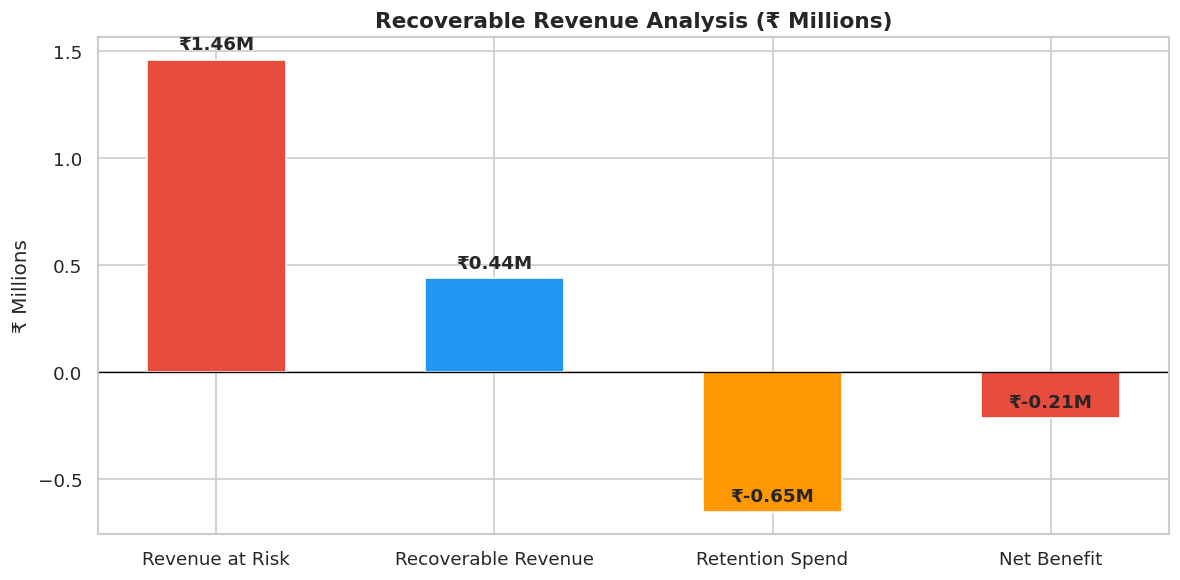

In [19]:
# RECOVERABLE REVENUE ESTIMATION


# Revenue recoverable if we retain a churning customer
# Assumption: 15% of CLV is at risk per churning customer
# Intervention success rate: 30% (industry benchmark)

CLV_AT_RISK_PCT       = 0.15   # % of CLV lost per churner
INTERVENTION_SUCCESS  = 0.30   # % of at-risk customers we save
RETENTION_SPEND_PER_C = 500    # ₹ per customer (FP cost proxy)

predicted_churners = scoring_df[scoring_df["churn_prediction"] == 1].copy()

# Revenue at risk per customer
predicted_churners["revenue_at_risk"] = (
    predicted_churners["customer_lifetime_value"]
    * CLV_AT_RISK_PCT
).round(0)

# Recoverable revenue
predicted_churners["recoverable_revenue"] = (
    predicted_churners["revenue_at_risk"]
    * INTERVENTION_SUCCESS
).round(0)

# Net benefit after retention spend
predicted_churners["net_benefit"] = (
    predicted_churners["recoverable_revenue"]
    - RETENTION_SPEND_PER_C
).round(0)

# Add to scoring_df
scoring_df = scoring_df.merge(
    predicted_churners[["customer_id", "revenue_at_risk", "recoverable_revenue", "net_benefit"]],
    on="customer_id", how="left"
)
scoring_df[["revenue_at_risk", "recoverable_revenue", "net_benefit"]] = (
    scoring_df[["revenue_at_risk", "recoverable_revenue", "net_benefit"]].fillna(0)
)

# Summary
total_at_risk    = predicted_churners["revenue_at_risk"].sum()
total_recoverable= predicted_churners["recoverable_revenue"].sum()
total_spend      = len(predicted_churners) * RETENTION_SPEND_PER_C
total_net        = total_recoverable - total_spend

print("=" * 60)
print(" RECOVERABLE REVENUE ESTIMATION")
print("=" * 60)
print(f"\n Predicted Churners       : {len(predicted_churners):,}")
print(f" Total Revenue at Risk    : ₹{total_at_risk:,.0f}")
print(f" Recoverable Revenue      : ₹{total_recoverable:,.0f}")
print(f" Retention Spend          : ₹{total_spend:,.0f}")
print(f" NET BENEFIT              : ₹{total_net:,.0f}")
print(f" ROI on Retention         : {total_net / (total_spend + 1):.1f}x")

# By wealth tier
print("\n Revenue by Wealth Tier:")
tier_rev = predicted_churners.groupby(
    scoring_df.loc[predicted_churners.index, "wealth_tier"] if "wealth_tier" in scoring_df.columns else "customer_id"
)[["revenue_at_risk", "recoverable_revenue"]].sum()

# Simpler groupby
predicted_churners_wt = predicted_churners.copy()
predicted_churners_wt["wealth_tier"] = scoring_df.set_index("customer_id").loc[
    predicted_churners["customer_id"], "wealth_tier"
].values

tier_rev = predicted_churners_wt.groupby("wealth_tier")[
    ["revenue_at_risk", "recoverable_revenue"]
].sum().sort_values("revenue_at_risk", ascending=False)
print(tier_rev.to_string())


# Revenue waterfall chart
fig, ax = plt.subplots(figsize=(10, 5))
categories = ["Revenue at Risk", "Recoverable Revenue", "Retention Spend", "Net Benefit"]
values     = [total_at_risk / 1e6, total_recoverable / 1e6, -total_spend / 1e6, total_net / 1e6]
colors     = ["#E74C3C", "#2196F3", "#FF9800", "#4CAF50" if total_net > 0 else "#E74C3C"]

bars = ax.bar(categories, values, color=colors, edgecolor="white", width=0.5)
ax.set_title("Recoverable Revenue Analysis (₹ Millions)", fontsize=13, fontweight="bold")
ax.set_ylabel("₹ Millions")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.02 * max(values)),
        f"₹{val:.2f}M",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/revenue_recovery.png", bbox_inches="tight")
plt.show()

Generating retention recommendations...

 RECOMMENDATION ENGINE — SUMMARY

 Top Recommended Actions:
recommended_action
Reactivation Offer: Waive Maintenance Fee for 3 Months    432
Priority Complaint Resolution + Service Recovery Offer    332
Standard Retention Email Campaign                         285
EMI Restructuring / Loan Holiday Offer                    198
Assign Dedicated Relationship Manager                      36
Priority Banking / Wealth Management Suite Upgrade         15
Cross-Sell Credit Card or Investment Product                3

 Expected Impact Distribution:
expected_impact
High      815
Low       285
Medium    201

 HIGH IMPACT customers for immediate attention: 815
 Recoverable revenue from High Impact segment : ₹301,186


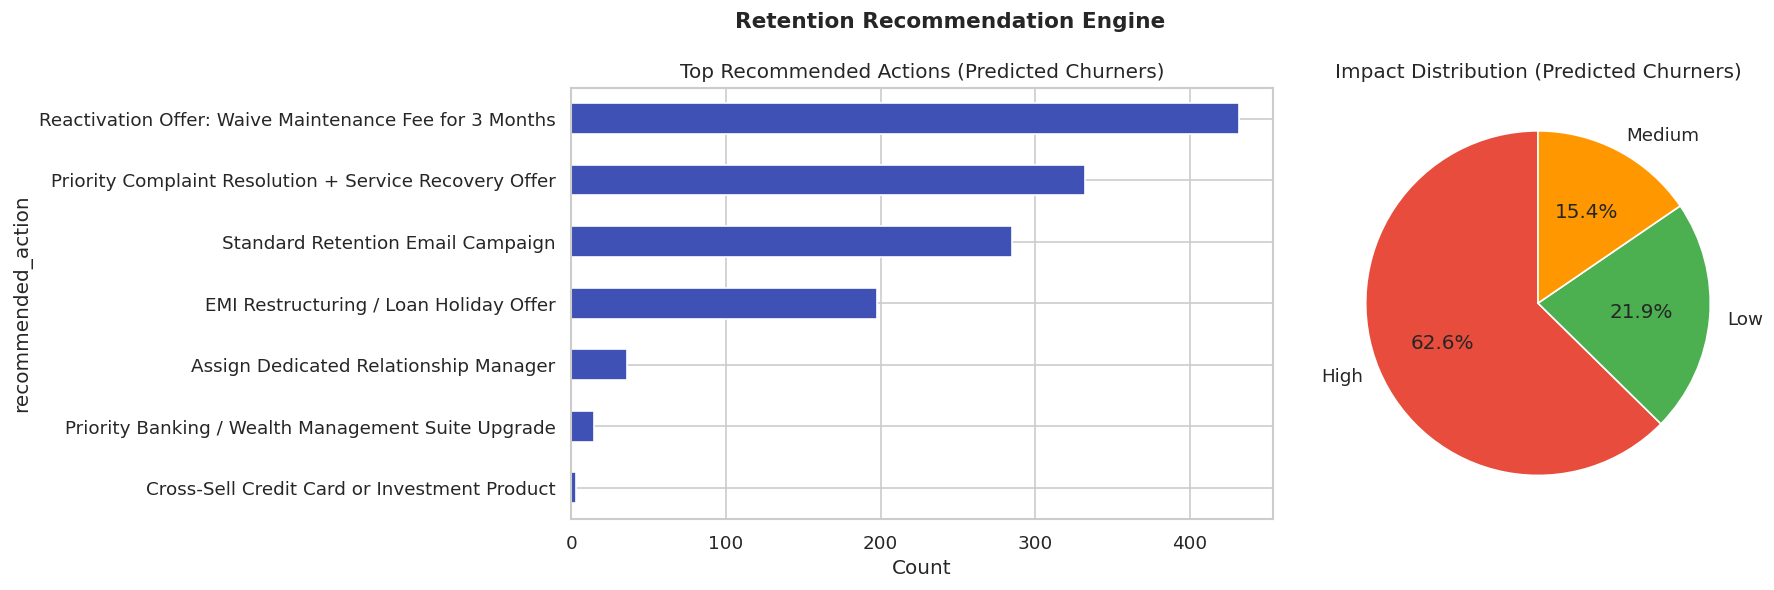


 Top 10 Customers to Save Immediately:
 customer_id  churn_probability risk_tier  priority_score  recoverable_revenue                    recommended_action expected_impact
      138226             0.9972  Critical          0.8152            1648.0000 Assign Dedicated Relationship Manager            High
      134471             0.9895  Critical          0.7506            1648.0000 Assign Dedicated Relationship Manager            High
      133242             0.9959  Critical          0.7473            1646.0000 Assign Dedicated Relationship Manager            High
      134736             0.9898  Critical          0.7402            1648.0000 Assign Dedicated Relationship Manager            High
      135190             0.9987  Critical          0.7397            1460.0000 Assign Dedicated Relationship Manager            High
      137061             0.9908  Critical          0.7383            1648.0000 Assign Dedicated Relationship Manager            High
      136273             0.99

In [20]:
#  RETENTION RECOMMENDATION ENGINE
# Rule-based + SHAP-guided personalized actions


def get_retention_recommendation(row):
    """
    RetentionFlow AI Recommendation Engine.
    Rules derived from SHAP top drivers + domain knowledge.
    Returns: recommended_action, reason, expected_impact, channel
    """
    actions = []

    # RULE 1 — HIGH VALUE + HIGH CHURN RISK
    if (
        row.get("customer_value", 0) > 0.6
        and row.get("churn_probability", 0) > 0.5
    ):
        actions.append({
            "action": "Assign Dedicated Relationship Manager",
            "reason": "High-value customer at critical churn risk — personal touch needed",
            "impact": "High",
            "channel": "Phone / In-branch",
            "priority": 1
        })

    # RULE 2 — COMPETITOR AWARENESS
    if row.get("competitor_aware_flag", 0) == 1:
        actions.append({
            "action": "Competitive Rate Match + Exclusive Offer",
            "reason": "Customer is actively evaluating competitor banks",
            "impact": "High",
            "channel": "Phone / Email",
            "priority": 1
        })

    # RULE 3 — ZERO / DECLINING BALANCE
    if row.get("zero_balance_flag", 0) == 1 or row.get("balance_declining_flag", 0) == 1:
        actions.append({
            "action": "Offer Fixed Deposit / High-Yield Savings Bonus",
            "reason": "Declining balance signals disengagement from deposits",
            "impact": "Medium",
            "channel": "App Notification / SMS",
            "priority": 2
        })

    # RULE 4 — SINGLE PRODUCT
    if row.get("single_product_flag", 0) == 1:
        actions.append({
            "action": "Cross-Sell Credit Card or Investment Product",
            "reason": "Single-product customers churn 2× more than multi-product",
            "impact": "Medium",
            "channel": "Email / App",
            "priority": 2
        })

    # RULE 5 — LOW DIGITAL ENGAGEMENT
    if row.get("low_digital_activity", 0) == 1:
        actions.append({
            "action": "Digital Re-engagement: App Tutorial + Cashback on Digital Txns",
            "reason": "Low digital activity predicts upcoming disengagement",
            "impact": "Medium",
            "channel": "SMS / Push Notification",
            "priority": 3
        })

    # RULE 6 — DORMANCY RISK
    if row.get("dormancy_risk_flag", 0) == 1:
        actions.append({
            "action": "Reactivation Offer: Waive Maintenance Fee for 3 Months",
            "reason": "Customer showing dormancy signals — last login and inactivity critical",
            "impact": "High",
            "channel": "Phone / Branch",
            "priority": 1
        })

    # RULE 7 — HIGH COMPLAINTS / ESCALATIONS
    if row.get("high_complaint_flag", 0) == 1 or row.get("escalation_count", 0) >= 2:
        actions.append({
            "action": "Priority Complaint Resolution + Service Recovery Offer",
            "reason": "Repeated complaints / escalations strongly linked to churn",
            "impact": "High",
            "channel": "Phone (Senior Support)",
            "priority": 1
        })

    # RULE 8 — FINANCIAL STRESS
    if row.get("financial_stress_flag", 0) == 1:
        actions.append({
            "action": "EMI Restructuring / Loan Holiday Offer",
            "reason": "High credit utilization or loan delays indicate financial stress",
            "impact": "Medium",
            "channel": "Phone / Branch",
            "priority": 2
        })

    # RULE 9 — LOW SATISFACTION
    if row.get("low_satisfaction_flag", 0) == 1:
        actions.append({
            "action": "Personal Outreach: Satisfaction Survey + Service Upgrade",
            "reason": "Low NPS / satisfaction score — proactive empathy outreach needed",
            "impact": "High",
            "channel": "Phone / Email",
            "priority": 1
        })

    # RULE 10 — ELITE / PREMIUM CUSTOMER NOT FULLY ENGAGED
    if (
        row.get("wealth_tier", "") in ["Elite", "Premium"]
        and row.get("churn_probability", 0) > 0.4
    ):
        actions.append({
            "action": "Priority Banking / Wealth Management Suite Upgrade",
            "reason": "Elite/Premium segment not receiving tier-appropriate engagement",
            "impact": "High",
            "channel": "Dedicated Banker",
            "priority": 1
        })

    # DEFAULT
    if not actions:
        actions.append({
            "action": "Standard Retention Email Campaign",
            "reason": "Low-risk customer — periodic engagement sufficient",
            "impact": "Low",
            "channel": "Email",
            "priority": 4
        })

    # Sort by priority and pick top action
    actions_sorted = sorted(actions, key=lambda x: x["priority"])
    top = actions_sorted[0]

    return pd.Series({
        "recommended_action":   top["action"],
        "recommendation_reason": top["reason"],
        "expected_impact":      top["impact"],
        "recommended_channel":  top["channel"],
        "num_risk_factors":     len(actions)
    })


# Apply only to predicted churners
print("Generating retention recommendations...")
recs = scoring_df.apply(get_retention_recommendation, axis=1)
scoring_df = pd.concat([scoring_df, recs], axis=1)

# Summary
print("\n" + "=" * 65)
print(" RECOMMENDATION ENGINE — SUMMARY")
print("=" * 65)
print("\n Top Recommended Actions:")
print(scoring_df[scoring_df["churn_prediction"] == 1]["recommended_action"].value_counts().head(10).to_string())

print("\n Expected Impact Distribution:")
print(scoring_df[scoring_df["churn_prediction"] == 1]["expected_impact"].value_counts().to_string())

# High impact customers
high_impact = scoring_df[
    (scoring_df["churn_prediction"] == 1)
    & (scoring_df["expected_impact"] == "High")
]
print(f"\n HIGH IMPACT customers for immediate attention: {len(high_impact):,}")
print(f" Recoverable revenue from High Impact segment : ₹{high_impact['recoverable_revenue'].sum():,.0f}")

# Action visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Retention Recommendation Engine", fontsize=13, fontweight="bold")

churners = scoring_df[scoring_df["churn_prediction"] == 1]

churners["recommended_action"].value_counts().head(8).plot(
    kind="barh", ax=axes[0], color="#3F51B5"
)
axes[0].set_title("Top Recommended Actions (Predicted Churners)")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

impact_colors = {"High": "#E74C3C", "Medium": "#FF9800", "Low": "#4CAF50"}
impact_counts = churners["expected_impact"].value_counts()
impact_counts.plot(
    kind="pie", ax=axes[1],
    colors=[impact_colors.get(i, "gray") for i in impact_counts.index],
    autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Impact Distribution (Predicted Churners)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/recommendations.png", bbox_inches="tight")
plt.show()

print("\n Top 10 Customers to Save Immediately:")
print(scoring_df.nlargest(10, "priority_score")[[
    "customer_id", "churn_probability", "risk_tier",
    "priority_score", "recoverable_revenue",
    "recommended_action", "expected_impact"
]].to_string(index=False))

In [22]:

# FINAL PREDICTIONS ON TEST SET

# Predict on submission test set
X_sub = X_val_scaled if BEST_MODEL_NAME == "LogisticRegression" else X_submission
test_prob = best_model.predict_proba(X_sub)[:, 1]
test_pred = (test_prob >= BEST_THRESHOLD).astype(int)

# Build submission CSV
submission_df = pd.DataFrame({
    "customer_id":        test_ids.values,
    "churn_prediction":   test_pred,
    "churn_probability":  test_prob.round(4)
})

# Validate
assert len(submission_df) == 2026, f"Row count mismatch! Got {len(submission_df)}"
assert submission_df["churn_prediction"].isin([0, 1]).all(), "Invalid predictions found"
assert submission_df["churn_probability"].between(0, 1).all(), "Probabilities out of range"
assert submission_df.isnull().sum().sum() == 0, "Nulls found in submission!"

# Save
submission_path = f"{OUTPUT_DIR}/ChurnZero_RetentionFlow_Predictions.csv"
submission_df.to_csv(submission_path, index=False)

print("=" * 60)
print(" PREDICTION EXPORT — VALIDATION PASSED ")
print("=" * 60)
print(f"\n Rows             : {len(submission_df):,}")
print(f" Predicted Churners: {test_pred.sum():,} ({test_pred.mean():.2%})")
print(f" Avg Probability  : {test_prob.mean():.4f}")
print(f" Saved to         : {submission_path}")
print(f"\n Sample predictions:")
print(submission_df.head(10).to_string(index=False))


# Detailed test scoring with recommendations
test_scoring_df = submission_df.copy()
test_scoring_df["risk_tier"] = test_scoring_df["churn_probability"].apply(assign_risk_tier)

# Bring in engineered features from test for recommendations
for col in [
    "customer_value", "zero_balance_flag", "single_product_flag",
    "low_digital_activity", "financial_stress_flag", "dormancy_risk_flag",
    "high_complaint_flag", "low_satisfaction_flag", "wealth_tier",
    "competitor_aware_flag", "escalation_count", "balance_declining_flag"
]:
    if col in df_test.columns:
        test_scoring_df[col] = df_test[col].values

test_recs = test_scoring_df.apply(get_retention_recommendation, axis=1)
test_scoring_df = pd.concat([test_scoring_df, test_recs], axis=1)
test_scoring_df["priority_score"] = (
    test_scoring_df["churn_probability"]
    * test_scoring_df.get("customer_value", 0.5)
).round(4)

full_test_path = f"{OUTPUT_DIR}/ChurnZero_RetentionFlow_FullTestScoring.csv"
test_scoring_df.to_csv(full_test_path, index=False)
print(f"\n Full test scoring saved: {full_test_path}")

 PREDICTION EXPORT — VALIDATION PASSED 

 Rows             : 2,026
 Predicted Churners: 324 (15.99%)
 Avg Probability  : 0.1591
 Saved to         : C:\Users\DELL\RetentionFlow\retention_flow_outputs/ChurnZero_RetentionFlow_Predictions.csv

 Sample predictions:
 customer_id  churn_prediction  churn_probability
   767114958                 0             0.0000
   708123033                 0             0.0005
   715424283                 0             0.0002
   717865008                 0             0.0000
   710188308                 0             0.0003
   716574033                 0             0.0000
   713183508                 0             0.0000
   718583133                 0             0.0005
   783554958                 0             0.0000
   714418158                 0             0.0000

 Full test scoring saved: C:\Users\DELL\RetentionFlow\retention_flow_outputs/ChurnZero_RetentionFlow_FullTestScoring.csv


In [32]:
# PRODUCTION ARTIFACT SAVING
# Model, scaler, encoders, config, feature list


import os
import json
import joblib

from datetime import datetime

artifacts_dir = f"{OUTPUT_DIR}/artifacts"

os.makedirs(
    artifacts_dir,
    exist_ok=True
)

# Save best model
model_path = f"{artifacts_dir}/retentionflow_best_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print(f"Model saved          : {model_path}")

# Save scaler
scaler_path = f"{artifacts_dir}/retentionflow_scaler.pkl"

joblib.dump(
    scaler,
    scaler_path
)

print(f"Scaler saved         : {scaler_path}")

# Save label encoders
le_path = f"{artifacts_dir}/retentionflow_encoders.pkl"

joblib.dump(
    le_dict,
    le_path
)

print(f"Encoders saved       : {le_path}")

# Save feature list
features_path = f"{artifacts_dir}/retentionflow_features.json"

with open(features_path, "w") as f:

    json.dump(
        list(X.columns),
        f,
        indent=2
    )

print(f"Feature list saved   : {features_path}")

# Save model config
config = {

    "model_name": BEST_MODEL_NAME,

    "threshold": round(
        float(BEST_THRESHOLD),
        4
    ),

    "fn_cost": FN_COST,

    "fp_cost": FP_COST,

    "random_state": RANDOM_STATE,

    "training_rows": len(df_train),

    "features": len(X.columns),

    "pr_auc": round(
        float(
            results_df.loc[
                BEST_MODEL_NAME,
                "PR_AUC"
            ]
        ),
        4
    ),

    "f1_score": round(
        float(
            results_df.loc[
                BEST_MODEL_NAME,
                "F1"
            ]
        ),
        4
    ),

    "timestamp": datetime.now().isoformat()
}

config_path = f"{artifacts_dir}/retentionflow_config.json"

with open(config_path, "w") as f:

    json.dump(
        config,
        f,
        indent=2
    )

print(f"Config saved         : {config_path}")

# Save SHAP feature importance
shap_importance.to_csv(
    f"{artifacts_dir}/shap_feature_importance.csv",
    index=False
)

print(
    f"SHAP importance saved: "
    f"{artifacts_dir}/shap_feature_importance.csv"
)

# Save model comparison results
results_df.to_csv(
    f"{artifacts_dir}/model_comparison_results.csv"
)

print(
    f"Model comparison     : "
    f"{artifacts_dir}/model_comparison_results.csv"
)

# Save full scoring for training set
scoring_df.to_csv(
    f"{OUTPUT_DIR}/retentionflow_train_scoring.csv",
    index=False
)

print(
    f"Train scoring saved  : "
    f"{OUTPUT_DIR}/retentionflow_train_scoring.csv"
)

print("\n" + "=" * 60)

print(" ALL PRODUCTION ARTIFACTS SAVED")

print("=" * 60)

# List all output files
all_files = []

for root, dirs, files in os.walk(OUTPUT_DIR):

    for file in files:

        fp = os.path.join(root, file)

        size = (
            os.path.getsize(fp)
            / 1024
        )

        all_files.append(
            (fp, f"{size:.1f} KB")
        )

print("\n Output directory contents:")

for fp, size in sorted(all_files):

    relative_fp = os.path.relpath(
        fp,
        OUTPUT_DIR
    )

    print(
        f"   {relative_fp}  ({size})"
    )

print(f"\n Total files: {len(all_files)}")

Model saved          : C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/retentionflow_best_model.pkl
Scaler saved         : C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/retentionflow_scaler.pkl
Encoders saved       : C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/retentionflow_encoders.pkl
Feature list saved   : C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/retentionflow_features.json
Config saved         : C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/retentionflow_config.json
SHAP importance saved: C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/shap_feature_importance.csv
Model comparison     : C:\Users\DELL\RetentionFlow\retention_flow_outputs/artifacts/model_comparison_results.csv
Train scoring saved  : C:\Users\DELL\RetentionFlow\retention_flow_outputs/retentionflow_train_scoring.csv

 ALL PRODUCTION ARTIFACTS SAVED

 Output directory contents:
   ChurnZero_RetentionFlow_FullTestScoring.csv  (377